# The complete oil and gas value chain: governed models, handoffs, and decisions

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/valuechain/complete_oil_and_gas_value_chain_with_neqsim.ipynb)

This expanded orientation notebook connects exploration, fluid characterization, reservoir
forecasting, wells, SURF, facilities, products, markets, operations, emissions, late life,
and decommissioning through governed model handoffs.

This conflict-resolved edition also preserves the connected process, PVT-support audit,
hydraulic, ISO 6976, probabilistic-value, and scenario-gate applications added on `master`.
Together they make the notebook a reusable lifecycle study rather than a collection of disconnected
screens.

The tool hierarchy is deliberate:

- **PVT laboratory data and a qualified specialist PVT package are the governing PVT basis.**
- Reservoir, well, multiphase-flow, reliability, market, and cost tools remain primary in
  their own disciplines.
- **NeqSim is supporting for PVT**: it independently checks selected states and translates
  the governed fluid into process, flow, energy, product-quality, and safety calculations.
- NeqSim is a primary open calculation engine for the integrated process examples shown here.

After running the notebook, the reader should be able to:

1. identify the owner and evidence behind every important model;
2. keep PVT, reservoir, process, and economic realizations internally consistent;
3. pass compositions, rates, pressures, temperatures, uncertainty, and identifiers across
   discipline boundaries;
4. locate the active production constraint and see how it changes over field life; and
5. distinguish screening evidence from decisions that require specialist studies.

All data are synthetic teaching data. Results are not reserves, design, operating,
commercial, safety, or decommissioning recommendations.


In [1]:
import importlib.util
import os
import subprocess
import sys

os.environ.setdefault(
    "MPLCONFIGDIR",
    "/tmp/neqsim-complete-value-chain-matplotlib",
)
SUPPORT_PACKAGES = {
    "IPython": "ipython",
    "jpype": "jpype1",
    "matplotlib": "matplotlib",
    "numpy": "numpy",
    "pandas": "pandas",
    "scipy": "scipy",
}
missing_packages = [
    package
    for module, package in SUPPORT_PACKAGES.items()
    if importlib.util.find_spec(module) is None
]
if missing_packages:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            "--quiet",
            "--no-cache-dir",
            *missing_packages,
        ],
        check=True,
        timeout=900,
    )
print("Python dependency gate passed.")


Python dependency gate passed.


In [2]:
from importlib.metadata import version
import hashlib
import platform
from pathlib import Path
import subprocess

from IPython.display import display
import jpype
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import interpolate, stats

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "legend.fontsize": 8,
    }
)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.float_format", lambda value: f"{value:,.4g}")

package_versions = pd.DataFrame(
    {
        "package": [
            "Python",
            "JPype",
            "NumPy",
            "Pandas",
            "SciPy",
            "Matplotlib",
        ],
        "version": [
            platform.python_version(),
            version("jpype1"),
            version("numpy"),
            version("pandas"),
            version("scipy"),
            version("matplotlib"),
        ],
    }
)
display(package_versions)


,package,version
0,Python,3.12.13
1,JPype,1.7.1
2,NumPy,2.3.5
3,Pandas,2.2.3
4,SciPy,1.17.0
5,Matplotlib,3.10.8


## Reproducible NeqSim Java `master` environment

The notebook builds NeqSim Java from `master` in a clean Colab runtime and records the exact
commit and JAR identity. A controlled validation environment may provide an already-built
source tree and JAR through environment variables; the class-source check still prevents a
different installed NeqSim artifact from being used accidentally.

Source-built NeqSim is used below as a **supporting thermodynamic/process service** and as the
process calculation engine. It is not used to regress or approve the governing PVT model.


In [3]:
def run_command(command, *, cwd=None, timeout=1200):
    result = subprocess.run(
        command,
        cwd=cwd,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        timeout=timeout,
    )
    if result.returncode != 0:
        tail = "\n".join(result.stdout.splitlines()[-80:])
        raise RuntimeError(
            f"Command failed ({result.returncode}): {command}\n{tail}"
        )
    return result.stdout.strip()


NEQSIM_SOURCE_REF = os.environ.get("NEQSIM_SOURCE_REF", "master")
supplied_source = os.environ.get("NEQSIM_SOURCE_ROOT", "").strip()
supplied_jar = os.environ.get("NEQSIM_SOURCE_JAR", "").strip()
supplied_commit = os.environ.get("NEQSIM_SOURCE_COMMIT", "").strip()

if supplied_source and supplied_jar:
    neqsim_source = Path(supplied_source).resolve()
    neqsim_jar = Path(supplied_jar).resolve()
    neqsim_commit = supplied_commit or run_command(
        ["git", "rev-parse", "HEAD"],
        cwd=neqsim_source,
    )
else:
    build_root = Path("/content") if Path("/content").exists() else Path.cwd()
    neqsim_source = build_root / "neqsim-java-master"
    if not neqsim_source.exists():
        run_command(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "--branch",
                NEQSIM_SOURCE_REF,
                "https://github.com/equinor/neqsim.git",
                str(neqsim_source),
            ],
            timeout=600,
        )
    else:
        run_command(
            ["git", "fetch", "--depth", "1", "origin", NEQSIM_SOURCE_REF],
            cwd=neqsim_source,
            timeout=600,
        )
        run_command(
            ["git", "checkout", "--detach", "FETCH_HEAD"],
            cwd=neqsim_source,
        )
    run_command(
        [
            "./mvnw",
            "-q",
            "-DskipTests",
            "-Dmaven.javadoc.skip=true",
            "package",
        ],
        cwd=neqsim_source,
        timeout=1500,
    )
    built_jars = sorted(
        path
        for path in (neqsim_source / "target").glob("neqsim-*.jar")
        if "sources" not in path.name
        and "javadoc" not in path.name
        and not path.name.startswith("original-")
    )
    if not built_jars:
        raise FileNotFoundError(
            "Maven completed but no NeqSim JAR was found."
        )
    neqsim_jar = built_jars[-1]
    neqsim_commit = run_command(
        ["git", "rev-parse", "HEAD"],
        cwd=neqsim_source,
    )

if not neqsim_source.is_dir() or not neqsim_jar.is_file():
    raise FileNotFoundError("NeqSim source root or built JAR is missing.")

neqsim_jar_sha256 = hashlib.sha256(neqsim_jar.read_bytes()).hexdigest()
os.environ["NEQSIM_JVM_AUTOSTART"] = "0"
if not jpype.isJVMStarted():
    jpype.addClassPath(str(neqsim_jar))
    local_m2 = os.environ.get("NEQSIM_VALIDATION_M2", "").strip()
    if local_m2:
        for dependency in sorted(Path(local_m2).rglob("*.jar")):
            if dependency.resolve() != neqsim_jar:
                jpype.addClassPath(str(dependency))
    jpype.startJVM()

JClass = jpype.JClass
MainOnlyClass = JClass(
    "neqsim.process.equipment.separator.ThreePhaseSeparator"
)
class_source = str(
    MainOnlyClass.class_.getProtectionDomain().getCodeSource().getLocation()
)
if neqsim_jar.name not in class_source:
    raise RuntimeError(
        "NeqSim classes were not loaded from the source-built JAR."
    )

java_runtime = run_command(["java", "-version"]).splitlines()[0]
provenance_table = pd.DataFrame(
    {
        "item": [
            "NeqSim source ref",
            "NeqSim commit",
            "JAR SHA-256",
            "Java runtime",
            "Java class source",
        ],
        "resolved value": [
            NEQSIM_SOURCE_REF,
            neqsim_commit,
            neqsim_jar_sha256,
            java_runtime,
            class_source,
        ],
    }
)
display(provenance_table)


,item,resolved value
0,NeqSim source ref,master
1,NeqSim commit,a1f7817d57e013d14da31991cc160b570ca0cb62
2,JAR SHA-256,7fc148e6d1fd28e09e8edfc37ce031a7c40f14aca31584bddcb82228e3bec095
3,Java runtime,"openjdk version ""17.0.19"" 2026-04-21"
4,Java class source,file:/tmp/neqsim-main-a1f7817d57e013d14da31991cc160b570ca0cb62.jar


## 1. Read the value chain as connected decisions

Discipline boundaries are physical and contractual handoffs, not disconnected models. At a
minimum, each handoff needs a case identifier, fluid/PVT identity, composition basis, rates,
pressure, temperature, uncertainty, validity range, and owner.

The basic component balance for component $i$ is

$$\dot{m}_{i,in}-\dot{m}_{i,out}-\frac{dM_i}{dt}=0$$

Steady screening uses $dM_i/dt=0$; linepack, separator level, start-up, shutdown, and slugging
studies must retain the accumulation term. Commercial, emissions, and economic results are
downstream of the same physical cases and must not silently mix unrelated percentiles.


,stage,governing evidence or tool,NeqSim contribution
0,Access and explore,"SODIR/GIS, seismic, wells, geoscience",Support fluid screens after samples exist
1,Sample and characterize fluids,PVT laboratory plus specialist PVT package,Support cross-checks and downstream translation; not PVT authority
2,Model reservoir and recovery,"Static model, OPM Flow or reservoir simulator, ERT",Support fluid/process boundary conditions
3,Design wells and completions,"Well model, completion and artificial-lift tools",Support fluid properties and integrated well/process screening
4,Design subsea and SURF,Detailed multiphase-flow and flow-assurance tools,Support early-phase hydraulics and thermodynamic boundaries
5,Process and condition,NeqSim process model plus specialist equipment tools,Primary open engine for integrated process calculations
6,Export and assure products,Laboratory/custody measurements and export network models,"Support quality prediction, energy, and terminal-state checks"
7,Market and optimize value,"Market, nominations, optimization, and fiscal models",Supply physical constraints to optimization and value models
8,"Operate, maintain, and improve","Historian, inspection, reliability, RAM, and digital twin","Support process twin, diagnosis, energy, and consequence models"
9,Manage late life and cessation,"Integrated subsurface, process, integrity, and economics","Support minimum-flow, water, energy, and inventory decisions"


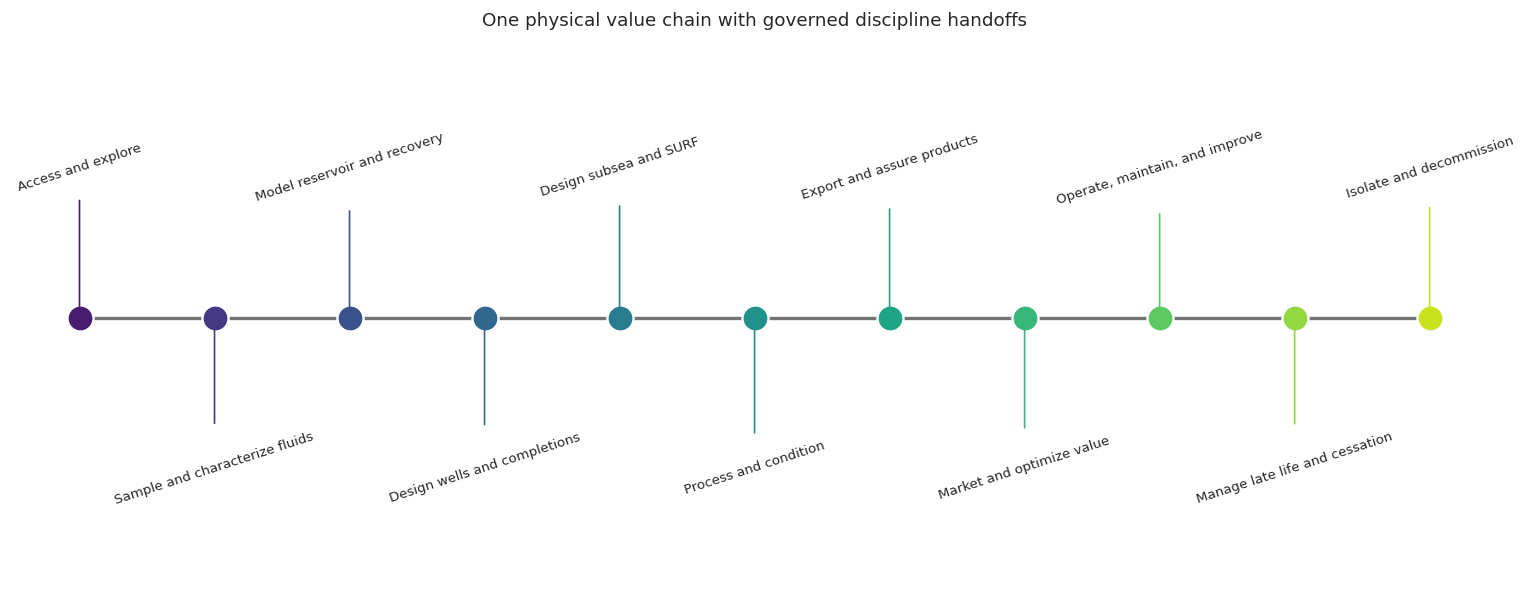

In [4]:
stages = pd.DataFrame(
    {
        "stage": [
            "Access and explore",
            "Sample and characterize fluids",
            "Model reservoir and recovery",
            "Design wells and completions",
            "Design subsea and SURF",
            "Process and condition",
            "Export and assure products",
            "Market and optimize value",
            "Operate, maintain, and improve",
            "Manage late life and cessation",
            "Isolate and decommission",
        ],
        "governing evidence or tool": [
            "SODIR/GIS, seismic, wells, geoscience",
            "PVT laboratory plus specialist PVT package",
            "Static model, OPM Flow or reservoir simulator, ERT",
            "Well model, completion and artificial-lift tools",
            "Detailed multiphase-flow and flow-assurance tools",
            "NeqSim process model plus specialist equipment tools",
            "Laboratory/custody measurements and export network models",
            "Market, nominations, optimization, and fiscal models",
            "Historian, inspection, reliability, RAM, and digital twin",
            "Integrated subsurface, process, integrity, and economics",
            "P&A, marine, structural, schedule, waste, and cost tools",
        ],
        "NeqSim contribution": [
            "Support fluid screens after samples exist",
            "Support cross-checks and downstream translation; not PVT authority",
            "Support fluid/process boundary conditions",
            "Support fluid properties and integrated well/process screening",
            "Support early-phase hydraulics and thermodynamic boundaries",
            "Primary open engine for integrated process calculations",
            "Support quality prediction, energy, and terminal-state checks",
            "Supply physical constraints to optimization and value models",
            "Support process twin, diagnosis, energy, and consequence models",
            "Support minimum-flow, water, energy, and inventory decisions",
            "Support inventory, depressurization, purge, and flushing cases",
        ],
    }
)
display(stages)

fig, axis = plt.subplots(figsize=(13, 5.2))
positions = np.arange(len(stages))
label_heights = np.where(positions % 2 == 0, 0.66, 0.34)
colors = plt.cm.viridis(np.linspace(0.08, 0.92, len(stages)))
axis.plot(positions, np.full(len(stages), 0.5), color="0.45", linewidth=2)
for index, row in stages.iterrows():
    axis.scatter(
        index,
        0.5,
        s=245,
        color=colors[index],
        edgecolor="white",
        linewidth=1.4,
        zorder=3,
    )
    axis.annotate(
        row["stage"],
        xy=(index, 0.5),
        xytext=(index, label_heights[index]),
        ha="center",
        va="center",
        fontsize=8,
        rotation=18,
        arrowprops={"arrowstyle": "-", "color": colors[index]},
    )
axis.set_xlim(-0.5, len(stages) - 0.5)
axis.set_ylim(0.2, 0.8)
axis.set_title("One physical value chain with governed discipline handoffs")
axis.axis("off")
plt.tight_layout()
plt.show()


## 2. Tool ownership and the explicit PVT boundary

The matrix uses three NeqSim roles:

- **2 — primary engine:** NeqSim directly calculates the integrated process result.
- **1 — supporting service:** NeqSim supplies a check, property, boundary, or consequence.
- **0 — external handoff:** another governed discipline tool owns the result.

`PVT authoring` is intentionally never assigned role 2. PVT experiments, characterization,
plus-fraction handling, EOS regression, uncertainty, and simulator export belong to the PVT
laboratory and a qualified specialist workflow. NeqSim consumes the approved model or a
documented translation and provides independent downstream evidence.


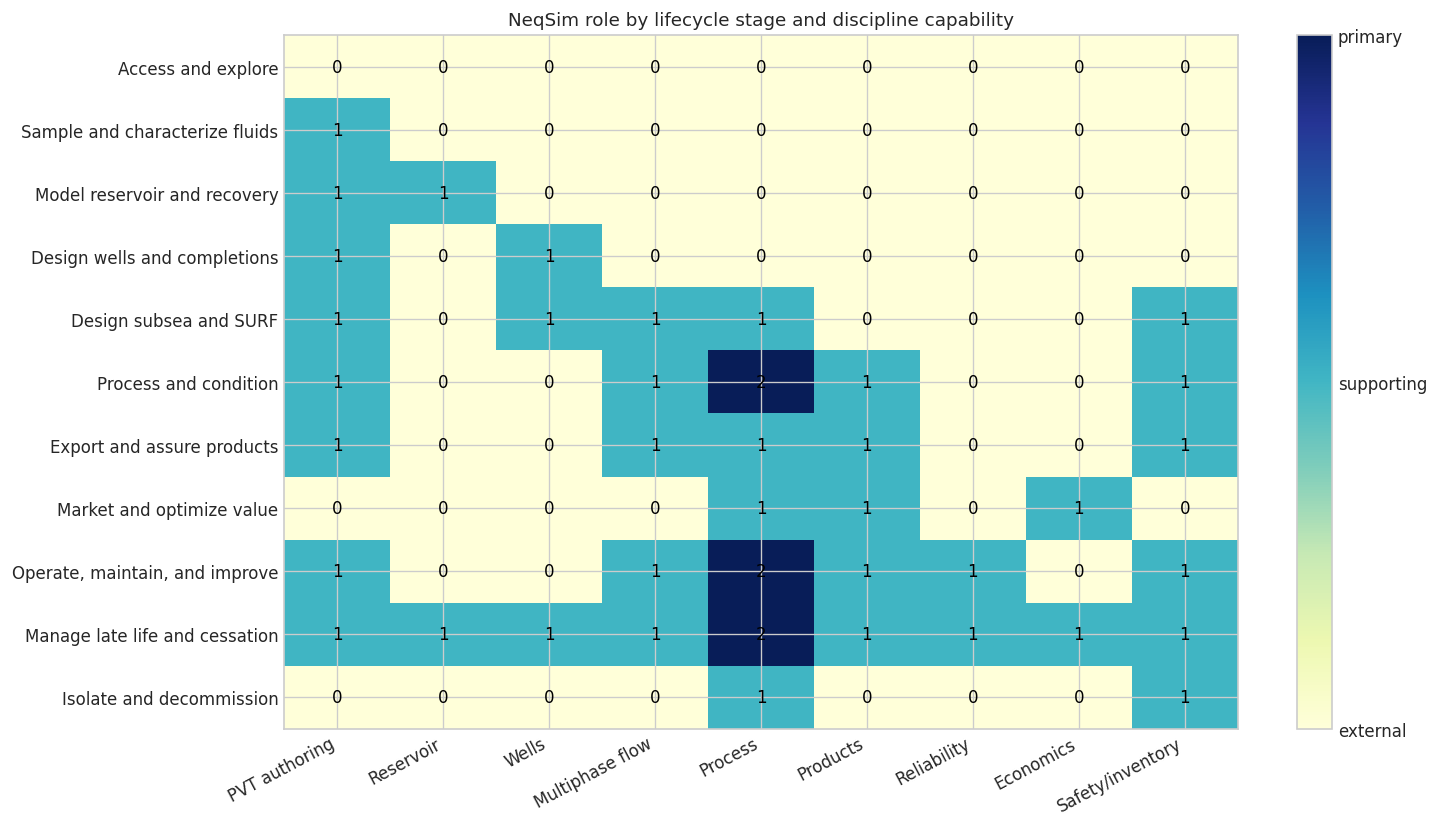

In [5]:
capabilities = [
    "PVT authoring",
    "Reservoir",
    "Wells",
    "Multiphase flow",
    "Process",
    "Products",
    "Reliability",
    "Economics",
    "Safety/inventory",
]
role_matrix = np.array(
    [
        [0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 0, 0, 0, 0, 0, 0, 0],
        [1, 0, 1, 0, 0, 0, 0, 0, 0],
        [1, 0, 1, 1, 1, 0, 0, 0, 1],
        [1, 0, 0, 1, 2, 1, 0, 0, 1],
        [1, 0, 0, 1, 1, 1, 0, 0, 1],
        [0, 0, 0, 0, 1, 1, 0, 1, 0],
        [1, 0, 0, 1, 2, 1, 1, 0, 1],
        [1, 1, 1, 1, 2, 1, 1, 1, 1],
        [0, 0, 0, 0, 1, 0, 0, 0, 1],
    ]
)

pvt_column = capabilities.index("PVT authoring")
assert role_matrix[:, pvt_column].max() <= 1

fig, axis = plt.subplots(figsize=(12.5, 7.0))
image = axis.imshow(
    role_matrix,
    cmap="YlGnBu",
    vmin=0,
    vmax=2,
    aspect="auto",
)
axis.set_xticks(np.arange(len(capabilities)), labels=capabilities)
axis.set_yticks(np.arange(len(stages)), labels=stages["stage"])
plt.setp(axis.get_xticklabels(), rotation=28, ha="right")
for row in range(role_matrix.shape[0]):
    for column in range(role_matrix.shape[1]):
        axis.text(
            column,
            row,
            str(role_matrix[row, column]),
            ha="center",
            va="center",
            color="black",
        )
axis.set_title("NeqSim role by lifecycle stage and discipline capability")
colorbar = fig.colorbar(image, ax=axis, ticks=[0, 1, 2])
colorbar.ax.set_yticklabels(["external", "supporting", "primary"])
plt.tight_layout()
plt.show()


## 3. Preserve model identity and internally consistent realizations

A number without provenance is not a safe handoff. The minimum contract used here carries a
`case_id` across PVT, reservoir, process, reliability, emissions, and economics. Low, base,
and high cases below are coherent teaching realizations; they are not independently combined
P10/P50/P90 values.

A production handoff is conceptually

$$H_k=\{k,f_k,z_k,p_k,T_k,\dot{m}_k,u_k,v_k,o_k\}$$

where $k$ is the case identifier, $f_k$ the fluid/PVT identity, $z_k$ composition, $u_k$
uncertainty metadata, $v_k$ validity limits, and $o_k$ the owning discipline.


In [6]:
scenario_registry = pd.DataFrame(
    {
        "case_id": ["LOW-001", "BASE-001", "HIGH-001"],
        "description": [
            "Lower connected volume and faster decline",
            "Reference integrated realization",
            "Higher connected volume and slower decline",
        ],
        "pvt_model_id": [
            "PVT-LAB-EOS-R03",
            "PVT-LAB-EOS-R03",
            "PVT-LAB-EOS-R03",
        ],
        "reservoir_model_id": ["RES-LOW-01", "RES-BASE-01", "RES-HIGH-01"],
        "well_network_id": ["WN-LOW-01", "WN-BASE-01", "WN-HIGH-01"],
        "process_model_id": [
            "NS-PROC-MASTER-R01",
            "NS-PROC-MASTER-R01",
            "NS-PROC-MASTER-R01",
        ],
        "reliability_id": ["RAM-LOW-01", "RAM-BASE-01", "RAM-HIGH-01"],
        "economic_id": ["ECON-LOW-01", "ECON-BASE-01", "ECON-HIGH-01"],
    }
)
contract_fields = pd.DataFrame(
    {
        "field": [
            "case_id",
            "model_id and revision",
            "composition and basis",
            "pressure and temperature",
            "phase and rate basis",
            "uncertainty and correlation",
            "validity range",
            "owner and approval state",
        ],
        "why it matters": [
            "Prevents mixing unrelated realizations",
            "Makes calculations reproducible",
            "Avoids mole/mass and pseudo-component ambiguity",
            "Keeps absolute/gauge and thermal state explicit",
            "Separates standard, actual, mass, and molar rates",
            "Preserves dependencies across disciplines",
            "Prevents extrapolation being mistaken for evidence",
            "Separates calculation from engineering approval",
        ],
    }
)
assert scenario_registry["case_id"].is_unique
display(scenario_registry)
display(contract_fields)


,case_id,description,pvt_model_id,reservoir_model_id,well_network_id,process_model_id,reliability_id,economic_id
0,LOW-001,Lower connected volume and faster decline,PVT-LAB-EOS-R03,RES-LOW-01,WN-LOW-01,NS-PROC-MASTER-R01,RAM-LOW-01,ECON-LOW-01
1,BASE-001,Reference integrated realization,PVT-LAB-EOS-R03,RES-BASE-01,WN-BASE-01,NS-PROC-MASTER-R01,RAM-BASE-01,ECON-BASE-01
2,HIGH-001,Higher connected volume and slower decline,PVT-LAB-EOS-R03,RES-HIGH-01,WN-HIGH-01,NS-PROC-MASTER-R01,RAM-HIGH-01,ECON-HIGH-01


,field,why it matters
0,case_id,Prevents mixing unrelated realizations
1,model_id and revision,Makes calculations reproducible
2,composition and basis,Avoids mole/mass and pseudo-component ambiguity
3,pressure and temperature,Keeps absolute/gauge and thermal state explicit
4,phase and rate basis,"Separates standard, actual, mass, and molar rates"
5,uncertainty and correlation,Preserves dependencies across disciplines
6,validity range,Prevents extrapolation being mistaken for evidence
7,owner and approval state,Separates calculation from engineering approval


## 4. PVT: laboratory and specialist model are primary

The governing workflow is: representative sampling and recombination → laboratory QA → CCE,
CVD, differential liberation, separator tests, density, viscosity, and swelling as relevant →
characterization and EOS regression in a specialist PVT environment → uncertainty review →
compositional description and/or simulator tables → reservoir and facilities handoff.

NeqSim is used after that gate to:

- reproduce selected independent states as a cross-check;
- translate the approved fluid into an auditable process-fluid representation;
- propagate composition into wells, SURF, separation, compression, utilities, and safety; and
- diagnose whether differences come from the PVT model, translation, or process assumptions.

The synthetic laboratory table below is the authoritative teaching dataset. The smooth lines
are interpolation only, not EOS regression. A real project must retain experiment uncertainty,
sample history, characterization choices, regression weights, and validity limits.


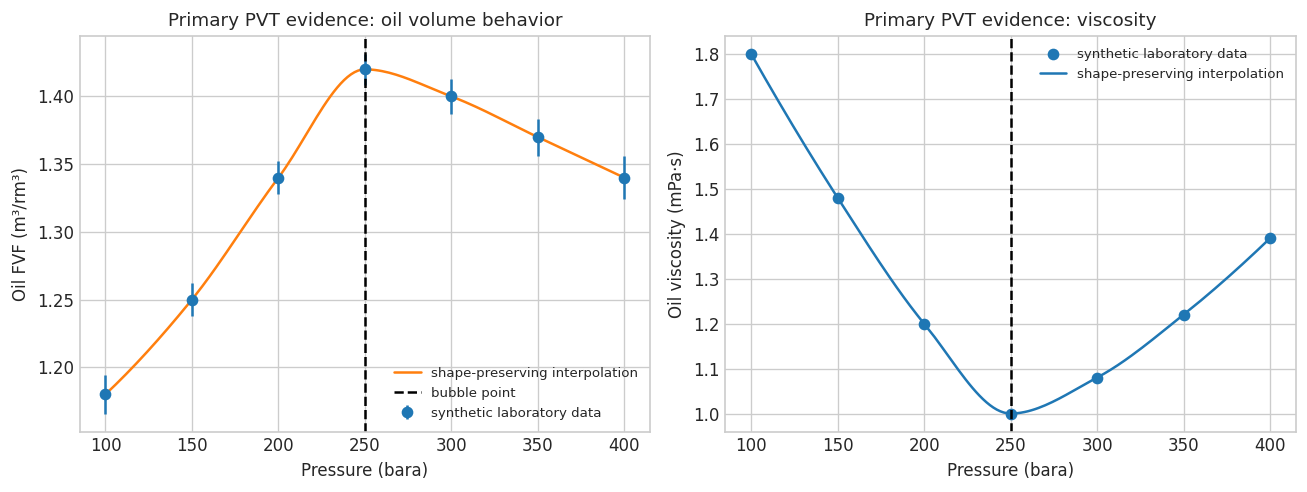

,pressure bara,oil FVF m3/rm3,solution GOR Sm3/Sm3,oil density kg/m3,oil viscosity mPa s,relative uncertainty %
0,100,1.18,110,790,1.8,1.2
1,150,1.25,140,770,1.48,1
2,200,1.34,173,748,1.2,0.9
3,250,1.42,205,728,1,0.8
4,300,1.4,205,735,1.08,0.9
5,350,1.37,205,744,1.22,1
6,400,1.34,205,753,1.39,1.2


,check,passed
0,Oil FVF peaks at the stated bubble point,True
1,Solution GOR is non-decreasing below bubble point,True
2,Solution GOR is constant above bubble point,True
3,Density and viscosity are positive and finite,True
4,Every measurement has uncertainty metadata,True


In [7]:
bubble_point_bara = 250.0
pvt_lab = pd.DataFrame(
    {
        "pressure bara": [100, 150, 200, 250, 300, 350, 400],
        "oil FVF m3/rm3": [1.18, 1.25, 1.34, 1.42, 1.40, 1.37, 1.34],
        "solution GOR Sm3/Sm3": [110, 140, 173, 205, 205, 205, 205],
        "oil density kg/m3": [790, 770, 748, 728, 735, 744, 753],
        "oil viscosity mPa s": [1.80, 1.48, 1.20, 1.00, 1.08, 1.22, 1.39],
        "relative uncertainty %": [1.2, 1.0, 0.9, 0.8, 0.9, 1.0, 1.2],
    }
)

below_bubble = pvt_lab["pressure bara"] <= bubble_point_bara
above_bubble = pvt_lab["pressure bara"] >= bubble_point_bara
pvt_quality_checks = pd.DataFrame(
    {
        "check": [
            "Oil FVF peaks at the stated bubble point",
            "Solution GOR is non-decreasing below bubble point",
            "Solution GOR is constant above bubble point",
            "Density and viscosity are positive and finite",
            "Every measurement has uncertainty metadata",
        ],
        "passed": [
            pvt_lab.loc[pvt_lab["oil FVF m3/rm3"].idxmax(), "pressure bara"]
            == bubble_point_bara,
            np.diff(
                pvt_lab.loc[below_bubble, "solution GOR Sm3/Sm3"]
            ).min()
            >= 0.0,
            np.ptp(
                pvt_lab.loc[above_bubble, "solution GOR Sm3/Sm3"]
            )
            < 1.0e-12,
            np.isfinite(
                pvt_lab[
                    ["oil density kg/m3", "oil viscosity mPa s"]
                ].to_numpy()
            ).all()
            and (
                pvt_lab[
                    ["oil density kg/m3", "oil viscosity mPa s"]
                ]
                > 0.0
            ).all().all(),
            (pvt_lab["relative uncertainty %"] > 0.0).all(),
        ],
    }
)
if not pvt_quality_checks["passed"].all():
    raise AssertionError(pvt_quality_checks.to_string(index=False))

pressure_grid = np.linspace(100.0, 400.0, 151)
bo_interpolator = interpolate.PchipInterpolator(
    pvt_lab["pressure bara"],
    pvt_lab["oil FVF m3/rm3"],
)
viscosity_interpolator = interpolate.PchipInterpolator(
    pvt_lab["pressure bara"],
    pvt_lab["oil viscosity mPa s"],
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].errorbar(
    pvt_lab["pressure bara"],
    pvt_lab["oil FVF m3/rm3"],
    yerr=(
        pvt_lab["oil FVF m3/rm3"]
        * pvt_lab["relative uncertainty %"]
        / 100.0
    ),
    fmt="o",
    label="synthetic laboratory data",
)
axes[0].plot(
    pressure_grid,
    bo_interpolator(pressure_grid),
    label="shape-preserving interpolation",
)
axes[0].axvline(
    bubble_point_bara,
    color="black",
    linestyle="--",
    label="bubble point",
)
axes[0].set(
    xlabel="Pressure (bara)",
    ylabel="Oil FVF (m³/rm³)",
    title="Primary PVT evidence: oil volume behavior",
)
axes[0].legend()

axes[1].scatter(
    pvt_lab["pressure bara"],
    pvt_lab["oil viscosity mPa s"],
    label="synthetic laboratory data",
)
axes[1].plot(
    pressure_grid,
    viscosity_interpolator(pressure_grid),
    label="shape-preserving interpolation",
)
axes[1].axvline(bubble_point_bara, color="black", linestyle="--")
axes[1].set(
    xlabel="Pressure (bara)",
    ylabel="Oil viscosity (mPa·s)",
    title="Primary PVT evidence: viscosity",
)
axes[1].legend()
plt.tight_layout()
plt.show()

display(pvt_lab)
display(pvt_quality_checks)


## 5. PVT support audit against synthetic laboratory observations

This section demonstrates the intended PVT boundary. The blue curve is a NeqSim SRK property
screen. The points are compact **synthetic laboratory observations** created for teaching; they are
not published experimental data. A PVT specialist would assess sample quality, select and tune the
fluid model, quantify uncertainty, and approve the reservoir-simulator representation. NeqSim is
used here to reproduce the governed basis and expose residuals for review.

The plotted residual is

$$

r_\rho=100\frac{\rho_{model}-\rho_{lab}}{\rho_{lab}}

$$

where density $\rho$ is in kg/m³. No parameter is tuned in this orientation example.


,pressure bara,synthetic lab density kg/m3,NeqSim density kg/m3,model residual %
0,20,16.65,16.46,-1.186
1,40,34.83,34.56,-0.794
2,60,54.14,54.36,0.402
3,80,75.94,75.71,-0.299
4,100,97.53,98.12,0.604
5,120,119.7,120.8,0.908


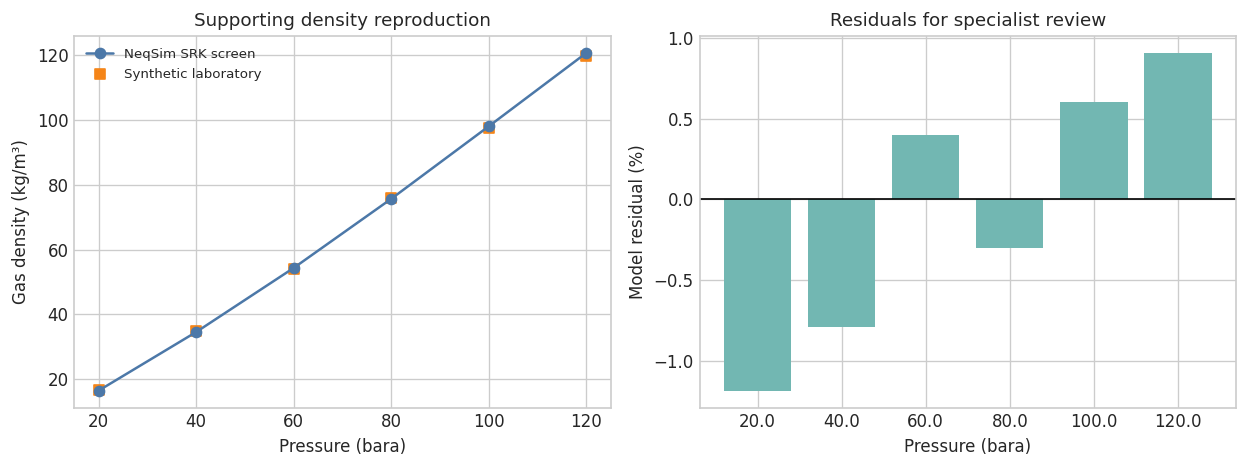

In [8]:
ThermodynamicOperations = JClass(
    "neqsim.thermodynamicoperations.ThermodynamicOperations"
)
SystemSrk = JClass("neqsim.thermo.system.SystemSrkEos")


def calculate_gas_density(pressure_bara, temperature_c=35.0):
    gas_fluid = SystemSrk(temperature_c + 273.15, pressure_bara)
    gas_composition = {
        "nitrogen": 0.01,
        "CO2": 0.03,
        "methane": 0.82,
        "ethane": 0.08,
        "propane": 0.04,
        "n-butane": 0.02,
    }
    for component, amount in gas_composition.items():
        gas_fluid.addComponent(component, amount)
    gas_fluid.setMixingRule(2)
    operations = ThermodynamicOperations(gas_fluid)
    operations.TPflash()
    gas_fluid.initPhysicalProperties()
    return gas_fluid.getPhase("gas").getDensity("kg/m3")


pvt_pressures_bara = np.array([20.0, 40.0, 60.0, 80.0, 100.0, 120.0])
model_density_kg_m3 = np.array(
    [calculate_gas_density(pressure) for pressure in pvt_pressures_bara]
)
synthetic_lab_offset = np.array([0.012, 0.008, -0.004, 0.003, -0.006, -0.009])
synthetic_lab_density_kg_m3 = model_density_kg_m3 * (1.0 + synthetic_lab_offset)
density_residual_percent = 100.0 * (
    model_density_kg_m3 - synthetic_lab_density_kg_m3
) / synthetic_lab_density_kg_m3

pvt_support_table = pd.DataFrame(
    {
        "pressure bara": pvt_pressures_bara,
        "synthetic lab density kg/m3": synthetic_lab_density_kg_m3,
        "NeqSim density kg/m3": model_density_kg_m3,
        "model residual %": density_residual_percent,
    }
)
display(pvt_support_table.round(3))

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.0))
axes[0].plot(
    pvt_pressures_bara,
    model_density_kg_m3,
    color="#4c78a8",
    marker="o",
    label="NeqSim SRK screen",
)
axes[0].scatter(
    pvt_pressures_bara,
    synthetic_lab_density_kg_m3,
    color="#f58518",
    marker="s",
    label="Synthetic laboratory",
)
axes[0].set(
    xlabel="Pressure (bara)",
    ylabel="Gas density (kg/m³)",
    title="Supporting density reproduction",
)
axes[0].legend()
axes[1].bar(
    pvt_pressures_bara.astype(str),
    density_residual_percent,
    color="#72b7b2",
)
axes[1].axhline(0.0, color="black", linewidth=1)
axes[1].set(
    xlabel="Pressure (bara)",
    ylabel="Model residual (%)",
    title="Residuals for specialist review",
)
plt.tight_layout()
plt.show()

assert np.all(np.diff(model_density_kg_m3) > 0.0)
assert np.max(np.abs(density_residual_percent)) < 2.0


The monotonic density trend is physically plausible and the synthetic residuals stay within 2%.
That is a QA observation, not an EOS-approval criterion. Real acceptance limits depend on the
measurement method, fluid class, depletion path, intended decision, and uncertainty agreed by the
PVT and reservoir teams.


## 6. Translate the approved PVT basis into a process-fluid contract

The compact NeqSim fluid below is a **documented downstream translation** used to demonstrate
process integration. It is not the approved reservoir PVT description, it is not regressed to
the synthetic table above, and its six components are too coarse for many real export, wax,
hydrate, and compositional-reservoir questions.

Three nearby flow cases are run to check process continuity. The calculation returns named gas,
oil-processing, and produced-water streams, closes mass, and supplies specific compression
demand for later integrated screening.


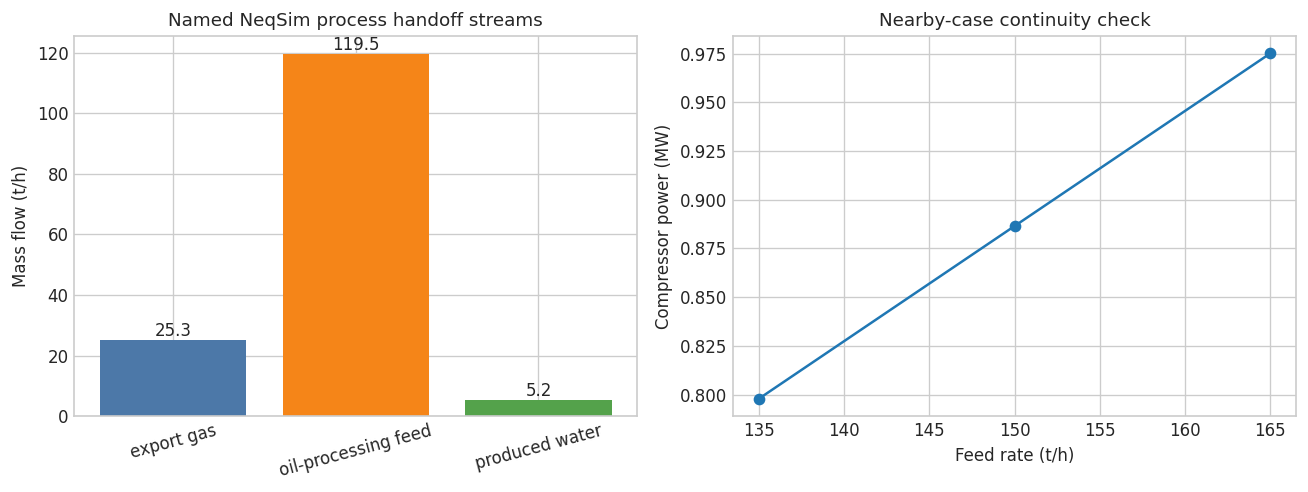

,stream,mass flow kg/h,next owner,model status
0,export gas,2.528e+04,gas treatment/export,screening process translation
1,oil-processing feed,1.195e+05,oil stabilization/export,screening process translation
2,produced water,"5,174",produced-water treatment,screening process translation


,feed kg/h,gas kg/h,oil-processing feed kg/h,produced water kg/h,relative mass residual,compressor power kW,gas outlet bara,gas outlet °C,oil outlet bara,water outlet bara
0,1.35e+05,2.275e+04,1.076e+05,"4,657",0,797.8,125,132.7,65,65
1,1.5e+05,2.528e+04,1.195e+05,"5,174",0,886.5,125,132.7,65,65
2,1.65e+05,2.781e+04,1.315e+05,"5,692",0,975.1,125,132.7,65,65


In [9]:
SystemSrkCPA = JClass("neqsim.thermo.system.SystemSrkCPAstatoil")
Stream = JClass("neqsim.process.equipment.stream.Stream")
ThreePhaseSeparator = JClass(
    "neqsim.process.equipment.separator.ThreePhaseSeparator"
)
Compressor = JClass("neqsim.process.equipment.compressor.Compressor")

process_feed_composition = {
    "methane": 48.0,
    "ethane": 6.0,
    "propane": 4.0,
    "n-heptane": 20.0,
    "nC10": 12.0,
    "water": 10.0,
}


def make_process_fluid():
    fluid = SystemSrkCPA(273.15 + 72.0, 65.0)
    for component, amount in process_feed_composition.items():
        fluid.addComponent(component, amount)
    fluid.setMixingRule(10)
    fluid.setMultiPhaseCheck(True)
    return fluid


def run_process_case(feed_rate_kg_h):
    wellstream = Stream("Field inlet", make_process_fluid())
    wellstream.setFlowRate(float(feed_rate_kg_h), "kg/hr")
    wellstream.run()

    separator = ThreePhaseSeparator(
        "HP three-phase separator",
        wellstream,
    )
    separator.run()
    gas_stream = separator.getGasOutStream()
    oil_stream = separator.getOilOutStream()
    water_stream = separator.getWaterOutStream()

    export_compressor = Compressor("Export compressor", gas_stream)
    export_compressor.setOutletPressure(125.0)
    export_compressor.setIsentropicEfficiency(0.78)
    export_compressor.run()

    gas_rate = float(gas_stream.getFlowRate("kg/hr"))
    oil_rate = float(oil_stream.getFlowRate("kg/hr"))
    water_rate = float(water_stream.getFlowRate("kg/hr"))
    total_out = gas_rate + oil_rate + water_rate
    relative_residual = abs(total_out - feed_rate_kg_h) / feed_rate_kg_h
    return {
        "feed kg/h": feed_rate_kg_h,
        "gas kg/h": gas_rate,
        "oil-processing feed kg/h": oil_rate,
        "produced water kg/h": water_rate,
        "relative mass residual": relative_residual,
        "compressor power kW": float(export_compressor.getPower("kW")),
        "gas outlet bara": float(
            export_compressor.getOutletStream().getPressure("bara")
        ),
        "gas outlet °C": float(
            export_compressor.getOutletStream().getTemperature("C")
        ),
        "oil outlet bara": float(oil_stream.getPressure("bara")),
        "water outlet bara": float(water_stream.getPressure("bara")),
    }


process_case_results = pd.DataFrame(
    [run_process_case(rate) for rate in [135_000.0, 150_000.0, 165_000.0]]
)
base_process = process_case_results.loc[
    process_case_results["feed kg/h"] == 150_000.0
].iloc[0]
assert process_case_results["relative mass residual"].max() < 1.0e-8
assert process_case_results["compressor power kW"].is_monotonic_increasing

handoff = pd.DataFrame(
    {
        "stream": [
            "export gas",
            "oil-processing feed",
            "produced water",
        ],
        "mass flow kg/h": [
            base_process["gas kg/h"],
            base_process["oil-processing feed kg/h"],
            base_process["produced water kg/h"],
        ],
        "next owner": [
            "gas treatment/export",
            "oil stabilization/export",
            "produced-water treatment",
        ],
        "model status": [
            "screening process translation",
            "screening process translation",
            "screening process translation",
        ],
    }
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
bars = axes[0].bar(
    handoff["stream"],
    handoff["mass flow kg/h"] / 1_000.0,
    color=["#4c78a8", "#f58518", "#54a24b"],
)
axes[0].bar_label(bars, fmt="%.1f")
axes[0].set(
    ylabel="Mass flow (t/h)",
    title="Named NeqSim process handoff streams",
)
axes[0].tick_params(axis="x", rotation=15)

axes[1].plot(
    process_case_results["feed kg/h"] / 1_000.0,
    process_case_results["compressor power kW"] / 1_000.0,
    marker="o",
)
axes[1].set(
    xlabel="Feed rate (t/h)",
    ylabel="Compressor power (MW)",
    title="Nearby-case continuity check",
)
plt.tight_layout()
plt.show()

display(handoff.round(3))
display(process_case_results.round(5))


## 7. Connected process scenarios: separation, compression, cooling, and gas quality

The next workflow is the practical backbone of the notebook. For each operating scenario it:

1. builds a fresh SRK-CPA fluid from a governed composition;
2. connects a `Stream`, `ThreePhaseSeparator`, `Compressor`, and `Cooler` in a `ProcessSystem`;
3. runs the connected process and checks unit status plus three-phase mass closure;
4. retrieves phase rates, power, cooling duty, and export-gas properties;
5. applies `Standard_ISO6976` for superior calorific value and Wobbe index.

The process balance is

$$

\dot{m}_{feed}-\sum_p\dot{m}_p=0

$$

where $p$ covers gas, oil, and aqueous separator outlets. Power and cooling duty are engineering
loads, while ISO 6976 values are commercial-quality handoffs at stated reference conditions.


,scenario,feed t/h,gas t/h,oil t/h,water t/h,compressor MW,cooling MW,gas MSm3/d,GCV MJ/Sm3,Wobbe MJ/Sm3,mass residual,process success
0,Reference,150,25.28,119.5,5.174,0.8865,2.137,0.7537,43.56,53.67,0,True
1,Turndown,90,15.17,71.73,3.104,0.5319,1.282,0.4522,43.56,53.67,0,True
2,High rate,180,30.34,143.5,6.209,1.064,2.564,0.9044,43.56,53.67,0,True
3,High water,150,24.23,114.6,11.16,0.8497,2.048,0.7224,43.56,53.67,0,True
4,CO2 rich,150,26.35,118.6,5.04,0.8258,2.053,0.708,40.8,47.71,0,True
5,Cold inlet,150,22.34,122.3,5.325,0.7448,1.321,0.6987,41.93,52.92,0,True


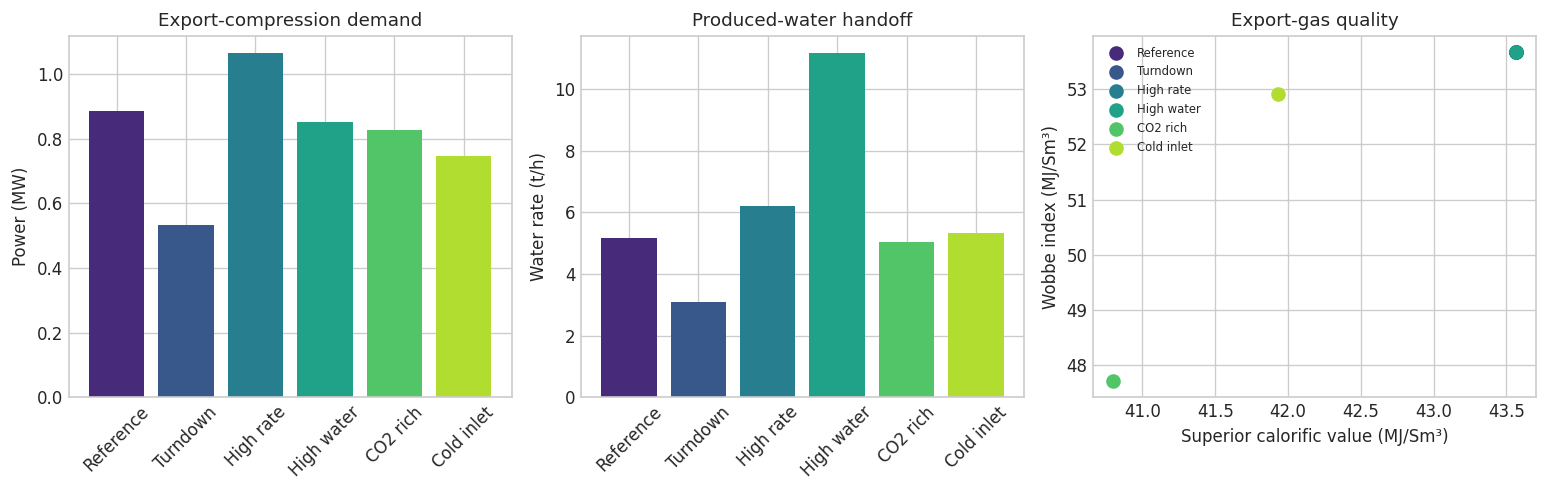

In [10]:
import json

Cooler = JClass("neqsim.process.equipment.heatexchanger.Cooler")
ProcessSystem = JClass("neqsim.process.processmodel.ProcessSystem")
StandardISO6976 = JClass("neqsim.standards.gasquality.Standard_ISO6976")

base_composition = {
    "methane": 48.0,
    "ethane": 6.0,
    "propane": 4.0,
    "n-heptane": 20.0,
    "nC10": 12.0,
    "water": 10.0,
}


def normalized_composition(composition):
    total = sum(composition.values())
    return {
        component: amount / total
        for component, amount in composition.items()
    }


def run_value_chain_case(name, flow_kg_h, temperature_c, pressure_bara, composition):
    fluid = SystemSrkCPA(temperature_c + 273.15, pressure_bara)
    for component, amount in composition.items():
        fluid.addComponent(component, amount)
    fluid.setMixingRule(10)
    fluid.setMultiPhaseCheck(True)

    feed = Stream(f"{name} feed", fluid)
    feed.setFlowRate(flow_kg_h, "kg/hr")
    separator_unit = ThreePhaseSeparator(f"{name} separator", feed)
    compressor_unit = Compressor(
        f"{name} compressor",
        separator_unit.getGasOutStream(),
    )
    compressor_unit.setOutletPressure(125.0)
    compressor_unit.setIsentropicEfficiency(0.78)
    cooler_unit = Cooler(f"{name} export cooler", compressor_unit.getOutletStream())
    cooler_unit.setOutTemperature(273.15 + 35.0)

    process = ProcessSystem()
    for unit in [feed, separator_unit, compressor_unit, cooler_unit]:
        process.add(unit)
    process.run()

    run_status = json.loads(str(process.getRunStatusJson()))
    gas_out = separator_unit.getGasOutStream()
    oil_out = separator_unit.getOilOutStream()
    water_out = separator_unit.getWaterOutStream()
    phase_flow_kg_h = np.array(
        [
            gas_out.getFlowRate("kg/hr"),
            oil_out.getFlowRate("kg/hr"),
            water_out.getFlowRate("kg/hr"),
        ]
    )
    mass_residual_fraction = abs(phase_flow_kg_h.sum() - flow_kg_h) / flow_kg_h

    export_stream = cooler_unit.getOutletStream()
    export_fluid = export_stream.getThermoSystem()
    export_fluid.init(2)
    export_standard = StandardISO6976(export_fluid)
    export_standard.setReferenceType("volume")
    export_standard.setReferenceState("real")
    export_standard.setVolRefT(15.0)
    export_standard.setEnergyRefT(25.0)
    export_standard.calculate()

    return {
        "scenario": name,
        "feed t/h": flow_kg_h / 1_000.0,
        "gas t/h": phase_flow_kg_h[0] / 1_000.0,
        "oil t/h": phase_flow_kg_h[1] / 1_000.0,
        "water t/h": phase_flow_kg_h[2] / 1_000.0,
        "compressor MW": compressor_unit.getPower("kW") / 1_000.0,
        "cooling MW": abs(cooler_unit.getDuty()) / 1.0e6,
        "gas MSm3/d": export_stream.getFlowRate("Sm3/day") / 1.0e6,
        "GCV MJ/Sm3": export_standard.getValue("SuperiorCalorificValue") / 1_000.0,
        "Wobbe MJ/Sm3": export_standard.getValue("SuperiorWobbeIndex") / 1_000.0,
        "mass residual": mass_residual_fraction,
        "process success": bool(run_status["success"]),
    }


scenario_definitions = [
    ("Reference", 150_000.0, 72.0, 65.0, base_composition),
    ("Turndown", 90_000.0, 72.0, 65.0, base_composition),
    ("High rate", 180_000.0, 72.0, 65.0, base_composition),
    (
        "High water",
        150_000.0,
        72.0,
        65.0,
        {**base_composition, "water": 22.0},
    ),
    (
        "CO2 rich",
        150_000.0,
        72.0,
        65.0,
        {**base_composition, "CO2": 5.0, "methane": 43.0},
    ),
    ("Cold inlet", 150_000.0, 45.0, 65.0, base_composition),
]

scenario_results = pd.DataFrame(
    [
        run_value_chain_case(
            name,
            flow_kg_h,
            temperature_c,
            pressure_bara,
            composition,
        )
        for name, flow_kg_h, temperature_c, pressure_bara, composition
        in scenario_definitions
    ]
)

assert scenario_results["process success"].all()
assert scenario_results["mass residual"].max() < 1.0e-8
display(scenario_results.round(4))

fig, axes = plt.subplots(1, 3, figsize=(13.0, 4.2))
scenario_colors = plt.cm.viridis(np.linspace(0.12, 0.88, len(scenario_results)))
axes[0].bar(
    scenario_results["scenario"],
    scenario_results["compressor MW"],
    color=scenario_colors,
)
axes[0].set(ylabel="Power (MW)", title="Export-compression demand")
axes[1].bar(
    scenario_results["scenario"],
    scenario_results["water t/h"],
    color=scenario_colors,
)
axes[1].set(ylabel="Water rate (t/h)", title="Produced-water handoff")
for (_, row), color in zip(scenario_results.iterrows(), scenario_colors):
    axes[2].scatter(
        row["GCV MJ/Sm3"],
        row["Wobbe MJ/Sm3"],
        color=color,
        s=60,
        label=row["scenario"],
    )
axes[2].set(
    xlabel="Superior calorific value (MJ/Sm³)",
    ylabel="Wobbe index (MJ/Sm³)",
    title="Export-gas quality",
)
axes[2].legend(fontsize=7, loc="best")
for axis in axes[:2]:
    axis.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


The high-rate case is the largest compression load, while the high-water case moves capacity into
the produced-water system. The CO₂-rich case shifts calorific value and Wobbe index even when the
equipment topology is unchanged. That is why a governed composition identifier must travel with
every scenario: a rate-only handoff is incomplete.


## 8. Reservoir forecasting is owned by the subsurface workflow

OPM Flow or another qualified reservoir simulator should generate production, injection,
pressure, and composition trajectories. ERT or an equivalent workflow should preserve
ensembles and data-assimilation history. NeqSim receives those trajectories; it does not
replace reservoir material balance, gridding, saturation functions, or history matching.

The three deterministic teaching realizations below mimic an imported forecast. Each retains
its own pressure decline, rate decline, and water development under one `case_id`.


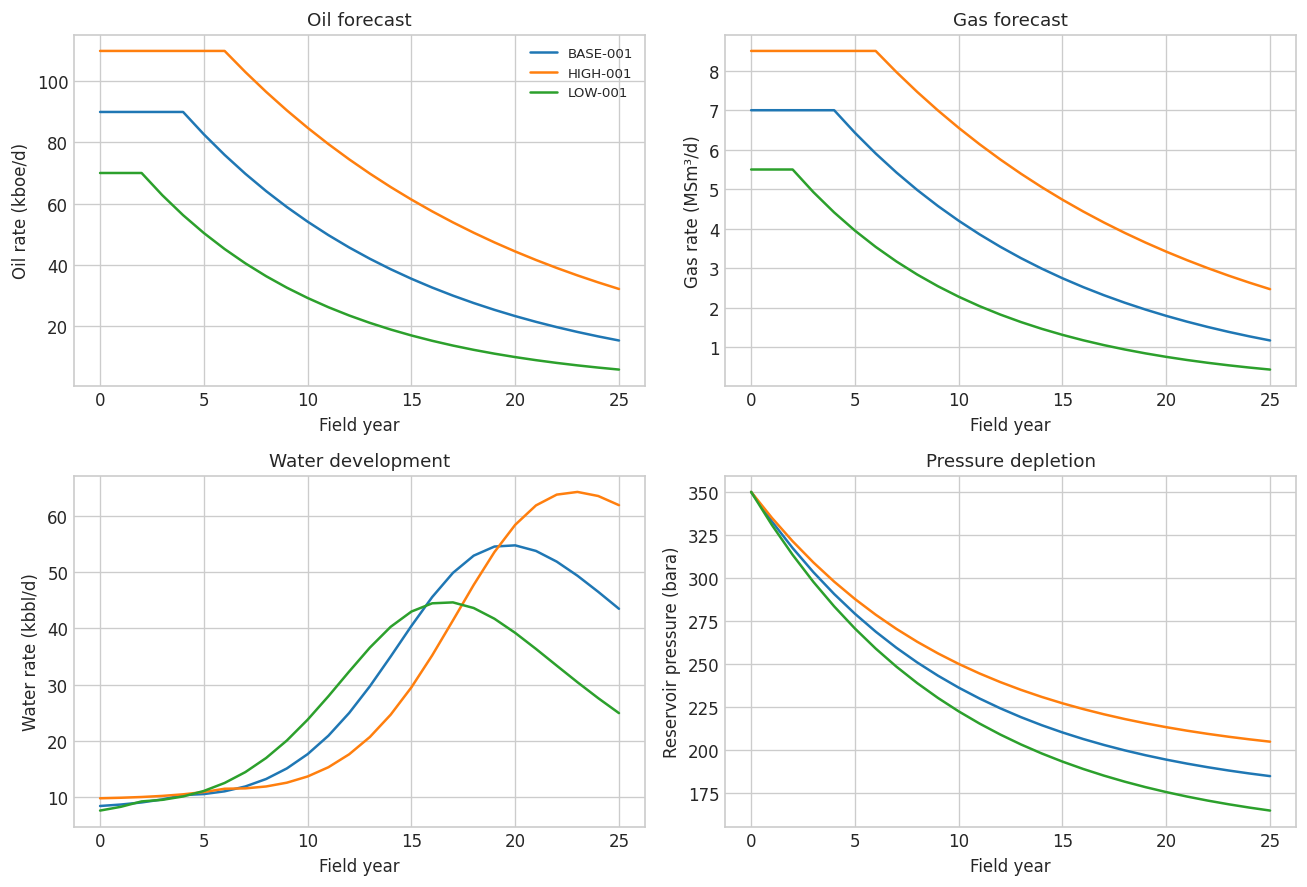

,case_id,year,oil kboe/d,gas MSm3/d,water kbbl/d,water cut,reservoir pressure bara
0,LOW-001,0,70,5.5,7.587,0.098,350
5,LOW-001,5,50.33,3.954,11.08,0.18,270.7
10,LOW-001,10,29.04,2.281,23.76,0.45,222.6
15,LOW-001,15,16.75,1.316,42.99,0.72,193.4
20,LOW-001,20,9.665,0.759,39.2,0.802,175.7
25,LOW-001,25,5.576,0.438,24.92,0.817,165
26,BASE-001,0,90,7,8.403,0.085,350
31,BASE-001,5,82.67,6.43,10.52,0.113,279.3
36,BASE-001,10,54.05,4.203,17.63,0.246,236.4
41,BASE-001,15,35.33,2.748,40.44,0.534,210.4


In [11]:
field_years = np.arange(0, 26)
reservoir_parameters = pd.DataFrame(
    {
        "case_id": ["LOW-001", "BASE-001", "HIGH-001"],
        "initial oil kboe/d": [70.0, 90.0, 110.0],
        "initial gas MSm3/d": [5.5, 7.0, 8.5],
        "plateau years": [2, 4, 6],
        "decline rate 1/y": [0.110, 0.085, 0.065],
        "final water cut": [0.82, 0.75, 0.68],
        "water midpoint y": [10.0, 13.0, 16.0],
        "final reservoir bara": [165.0, 185.0, 205.0],
    }
)

forecast_records = []
for _, parameters in reservoir_parameters.iterrows():
    decline_time = np.maximum(
        field_years - parameters["plateau years"],
        0.0,
    )
    hydrocarbon_factor = np.exp(
        -parameters["decline rate 1/y"] * decline_time
    )
    water_cut = 0.08 + (
        parameters["final water cut"] - 0.08
    ) / (
        1.0
        + np.exp(
            -(field_years - parameters["water midpoint y"]) / 2.7
        )
    )
    oil_rate = parameters["initial oil kboe/d"] * hydrocarbon_factor
    gas_rate = parameters["initial gas MSm3/d"] * hydrocarbon_factor
    total_liquid = oil_rate / np.maximum(1.0 - water_cut, 0.05)
    water_rate = total_liquid * water_cut
    pressure_fraction = (
        1.0 - np.exp(-field_years / 10.0)
    ) / (
        1.0 - np.exp(-field_years[-1] / 10.0)
    )
    reservoir_pressure = 350.0 - pressure_fraction * (
        350.0 - parameters["final reservoir bara"]
    )
    for index, year in enumerate(field_years):
        forecast_records.append(
            {
                "case_id": parameters["case_id"],
                "year": int(year),
                "oil kboe/d": oil_rate[index],
                "gas MSm3/d": gas_rate[index],
                "water kbbl/d": water_rate[index],
                "water cut": water_cut[index],
                "reservoir pressure bara": reservoir_pressure[index],
            }
        )

reservoir_forecast = pd.DataFrame(forecast_records)
assert set(reservoir_forecast["case_id"]) == set(
    scenario_registry["case_id"]
)

fig, axes = plt.subplots(2, 2, figsize=(11, 7.5))
plot_specs = [
    ("oil kboe/d", "Oil rate (kboe/d)", "Oil forecast"),
    ("gas MSm3/d", "Gas rate (MSm³/d)", "Gas forecast"),
    ("water kbbl/d", "Water rate (kbbl/d)", "Water development"),
    (
        "reservoir pressure bara",
        "Reservoir pressure (bara)",
        "Pressure depletion",
    ),
]
for axis, (column, ylabel, title) in zip(axes.flat, plot_specs):
    for case_id, group in reservoir_forecast.groupby("case_id"):
        axis.plot(group["year"], group[column], label=case_id)
    axis.set(xlabel="Field year", ylabel=ylabel, title=title)
axes[0, 0].legend()
plt.tight_layout()
plt.show()

display(reservoir_forecast.query("year in [0, 5, 10, 15, 20, 25]").round(3))


## 9. Wells and SURF: retain pressure and capacity margins

Detailed completion, lift, injection, erosion, terrain, slugging, hydrate, wax, corrosion, and
transient studies belong in specialist well and multiphase-flow tools. NeqSim can support fluid
properties, early-phase hydraulics, receiving conditions, and integration with topside control.

The reduced screen below asks two bounded questions: is there positive wellhead-pressure margin,
and is the shared flowline below its illustrative capacity? A negative margin is a trigger for a
lower-pressure operating mode, artificial lift, boosting, compression, debottlenecking, or a
revised production strategy—not a design answer.


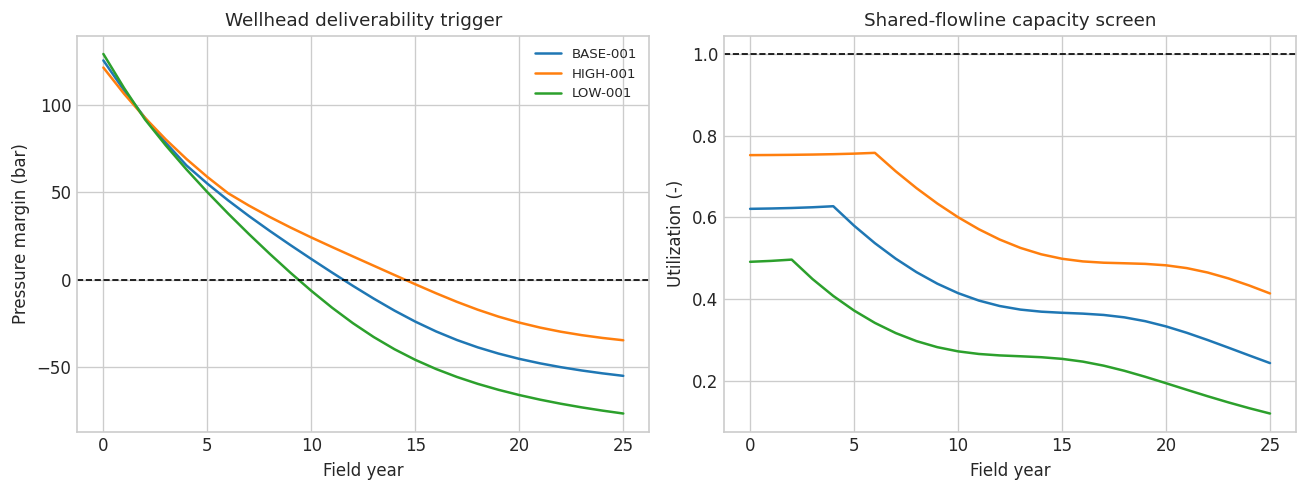

,first assistance-trigger year
case_id,
BASE-001,12
HIGH-001,15
LOW-001,10


In [12]:
flow_screen = reservoir_forecast.copy()
flow_screen["drawdown bar"] = (
    18.0
    + 0.18 * flow_screen["oil kboe/d"]
    + 16.0 * flow_screen["water cut"]
)
flow_screen["available wellhead bara"] = (
    flow_screen["reservoir pressure bara"]
    - flow_screen["drawdown bar"]
    - 105.0
)
flow_screen["required wellhead bara"] = (
    78.0
    + 0.45 * flow_screen["gas MSm3/d"]
    + 32.0 * flow_screen["water cut"]
)
flow_screen["wellhead margin bar"] = (
    flow_screen["available wellhead bara"]
    - flow_screen["required wellhead bara"]
)
flow_screen["flowline utilization"] = (
    0.72 * flow_screen["gas MSm3/d"] / 8.5
    + 0.28 * flow_screen["water kbbl/d"] / 85.0
)
flow_screen["assistance trigger"] = (
    flow_screen["wellhead margin bar"] < 0.0
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for case_id, group in flow_screen.groupby("case_id"):
    axes[0].plot(
        group["year"],
        group["wellhead margin bar"],
        label=case_id,
    )
    axes[1].plot(
        group["year"],
        group["flowline utilization"],
        label=case_id,
    )
axes[0].axhline(0.0, color="black", linestyle="--", linewidth=1)
axes[0].set(
    xlabel="Field year",
    ylabel="Pressure margin (bar)",
    title="Wellhead deliverability trigger",
)
axes[0].legend()
axes[1].axhline(1.0, color="black", linestyle="--", linewidth=1)
axes[1].set(
    xlabel="Field year",
    ylabel="Utilization (-)",
    title="Shared-flowline capacity screen",
)
plt.tight_layout()
plt.show()

first_assistance = (
    flow_screen.loc[flow_screen["assistance trigger"]]
    .groupby("case_id")["year"]
    .min()
    .rename("first assistance-trigger year")
)
display(first_assistance.to_frame())


## 10. SURF hydraulic screening from the governed process state

A preliminary single-phase gas screen translates NeqSim density and viscosity into velocity,
Reynolds number, Darcy friction factor, and pressure gradient. For pipe length $L$, diameter $D$,
density $\rho$, and velocity $v$,

$$

\Delta p=f\frac{L}{D}\frac{\rho v^2}{2}

$$

This is useful for consistency checks and early option comparison. It does **not** replace a
multiphase flow-assurance model, terrain profile, heat-transfer model, transient analysis, slugging
study, erosion assessment, or detailed pipeline design.


,mass flow kg/s,velocity m/s,Reynolds number,Darcy friction factor,pressure drop bar
0,4,0.1716,6.113e+05,0.0139,0.0292
1,6.5,0.2788,9.934e+05,0.0132,0.0734
2,9,0.3861,1.376e+06,0.0129,0.137
3,11.5,0.4933,1.758e+06,0.0127,0.2197
4,14,0.6006,2.14e+06,0.0125,0.3216
5,16.5,0.7078,2.522e+06,0.0124,0.4425
6,19,0.8151,2.904e+06,0.0123,0.5825
7,21.5,0.9223,3.286e+06,0.0122,0.7416
8,24,1.03,3.668e+06,0.0122,0.9197


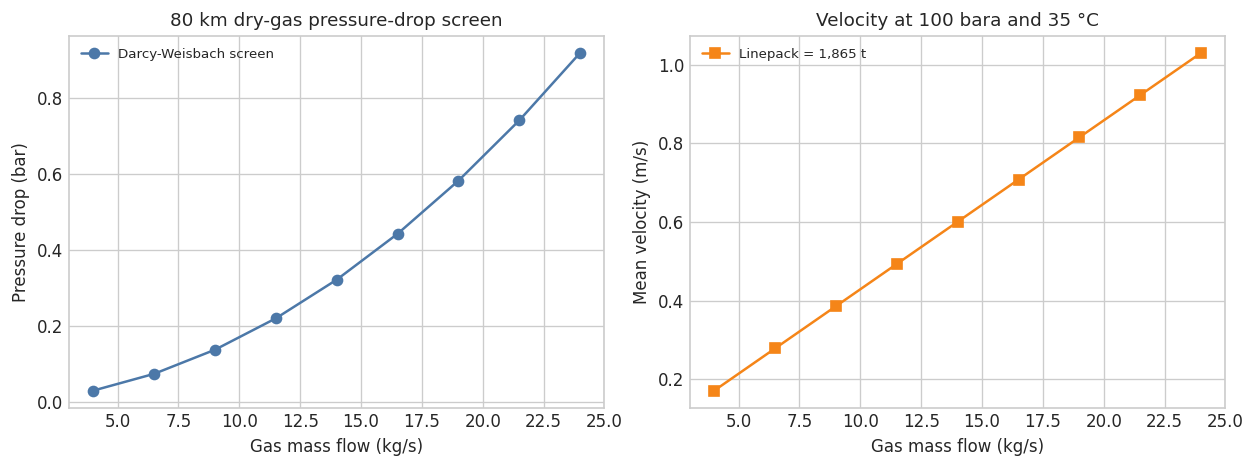

In [13]:
screen_temperature_c = 35.0
screen_pressure_bara = 100.0
screen_fluid = SystemSrk(screen_temperature_c + 273.15, screen_pressure_bara)
for component, amount in {
    "nitrogen": 0.01,
    "CO2": 0.03,
    "methane": 0.82,
    "ethane": 0.08,
    "propane": 0.04,
    "n-butane": 0.02,
}.items():
    screen_fluid.addComponent(component, amount)
screen_fluid.setMixingRule(2)
ThermodynamicOperations(screen_fluid).TPflash()
screen_fluid.initPhysicalProperties()
screen_phase = screen_fluid.getPhase("gas")
screen_density_kg_m3 = screen_phase.getDensity("kg/m3")
screen_viscosity_pa_s = screen_phase.getViscosity("kg/msec")

pipe_length_m = 80_000.0
pipe_diameter_m = 0.55
pipe_roughness_m = 4.5e-5
pipe_area_m2 = np.pi * pipe_diameter_m**2 / 4.0
screen_mass_flow_kg_s = np.linspace(4.0, 24.0, 9)
screen_velocity_m_s = screen_mass_flow_kg_s / (screen_density_kg_m3 * pipe_area_m2)
screen_reynolds = (
    screen_density_kg_m3
    * screen_velocity_m_s
    * pipe_diameter_m
    / screen_viscosity_pa_s
)
relative_roughness = pipe_roughness_m / pipe_diameter_m
screen_friction_factor = 0.25 / (
    np.log10(relative_roughness / 3.7 + 5.74 / screen_reynolds**0.9) ** 2
)
screen_pressure_drop_bar = (
    screen_friction_factor
    * pipe_length_m
    / pipe_diameter_m
    * screen_density_kg_m3
    * screen_velocity_m_s**2
    / 2.0
    / 1.0e5
)
screen_linepack_tonnes = (
    screen_density_kg_m3 * pipe_area_m2 * pipe_length_m / 1_000.0
)

hydraulic_screen = pd.DataFrame(
    {
        "mass flow kg/s": screen_mass_flow_kg_s,
        "velocity m/s": screen_velocity_m_s,
        "Reynolds number": screen_reynolds,
        "Darcy friction factor": screen_friction_factor,
        "pressure drop bar": screen_pressure_drop_bar,
    }
)
display(hydraulic_screen.round(4))

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.0))
axes[0].plot(
    screen_mass_flow_kg_s,
    screen_pressure_drop_bar,
    color="#4c78a8",
    marker="o",
    label="Darcy-Weisbach screen",
)
axes[0].set(
    xlabel="Gas mass flow (kg/s)",
    ylabel="Pressure drop (bar)",
    title="80 km dry-gas pressure-drop screen",
)
axes[0].legend()
axes[1].plot(
    screen_mass_flow_kg_s,
    screen_velocity_m_s,
    color="#f58518",
    marker="s",
    label=f"Linepack = {screen_linepack_tonnes:,.0f} t",
)
axes[1].set(
    xlabel="Gas mass flow (kg/s)",
    ylabel="Mean velocity (m/s)",
    title="Velocity at 100 bara and 35 °C",
)
axes[1].legend()
plt.tight_layout()
plt.show()

assert np.all(np.diff(screen_pressure_drop_bar) > 0.0)
assert np.all(screen_reynolds > 4_000.0)


Pressure loss rises faster than flow because velocity and dynamic pressure increase together. The
screen also reports the thermodynamic state behind its density, viscosity, and linepack. A project
handoff would add the elevation profile, wall and insulation data, fluid uncertainty, operating
envelope, and explicit criteria for escalation to steady or transient multiphase analysis.


## 11. Facilities: re-evaluate the active constraint over field life

The NeqSim process cases provide phase split and specific compression demand at the reference
inlet. The screening model scales those quantities with the imported reservoir realizations.
This is suitable for explaining coupling and prioritizing detailed cases, not for final sizing.

Capacity utilization for service $j$ is

$$U_j(t,k)=\frac{L_j(t,k)}{C_j(t,k)}$$

The largest $U_j$ identifies the active screening bottleneck. A mature model should re-run the
complete compositional process for every selected reservoir realization and operating state,
including recycle, equipment maps, turndown, ambient conditions, and control constraints.


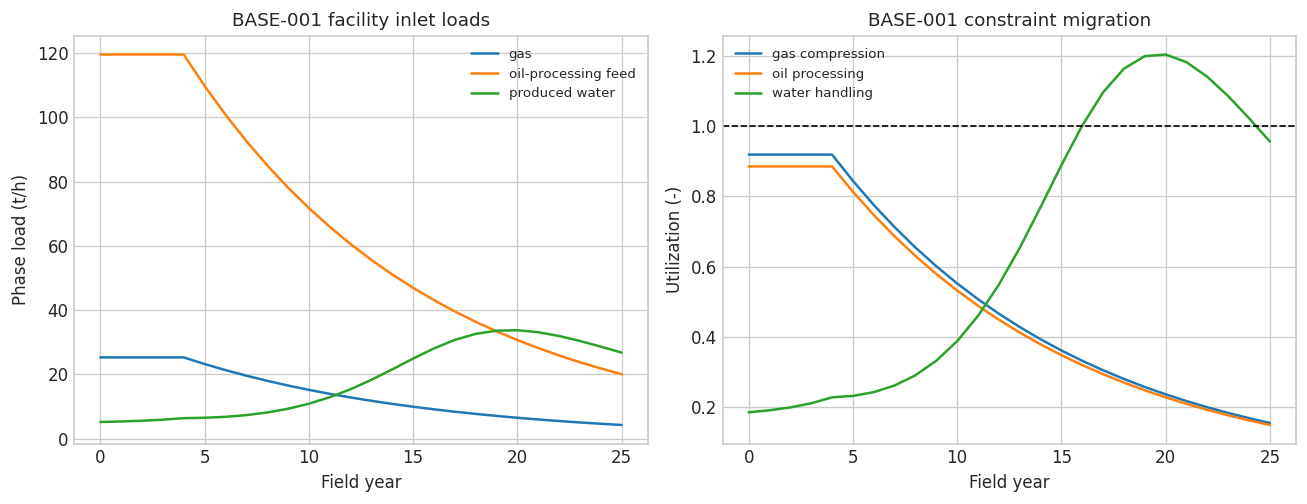

,case_id,year,gas load t/h,oil load t/h,water load t/h,compression MW,maximum utilization,active constraint
0,LOW-001,0,19.86,92.98,4.672,0.697,0.722,gas compression
10,LOW-001,10,8.239,38.57,14.63,0.289,0.522,water handling
20,LOW-001,20,2.742,12.84,24.14,0.096,0.862,water handling
25,LOW-001,25,1.582,7.407,15.35,0.055,0.548,water handling
26,BASE-001,0,25.28,119.5,5.174,0.886,0.919,gas compression
36,BASE-001,10,15.18,71.79,10.85,0.532,0.552,gas compression
46,BASE-001,20,6.488,30.68,33.73,0.228,1.205,water handling
51,BASE-001,25,4.242,20.06,26.78,0.149,0.956,water handling
52,HIGH-001,0,30.7,146.1,6.018,1.076,1.116,gas compression
62,HIGH-001,10,23.67,112.7,8.408,0.83,0.861,gas compression


In [14]:
base_reservoir = reservoir_forecast.query("case_id == 'BASE-001' and year == 0").iloc[0]
facility = reservoir_forecast.copy()
facility["gas load t/h"] = (
    base_process["gas kg/h"]
    / 1_000.0
    * facility["gas MSm3/d"]
    / base_reservoir["gas MSm3/d"]
)
facility["oil load t/h"] = (
    base_process["oil-processing feed kg/h"]
    / 1_000.0
    * facility["oil kboe/d"]
    / base_reservoir["oil kboe/d"]
)
facility["water load t/h"] = (
    base_process["produced water kg/h"]
    / 1_000.0
    * facility["water kbbl/d"]
    / base_reservoir["water kbbl/d"]
)
facility["compression MW"] = (
    base_process["compressor power kW"]
    / 1_000.0
    * facility["gas load t/h"]
    / (base_process["gas kg/h"] / 1_000.0)
)

facility_capacities = {
    "gas compression": 27.5,
    "oil processing": 135.0,
    "water handling": 28.0,
}
facility["gas compression"] = (
    facility["gas load t/h"]
    / facility_capacities["gas compression"]
)
facility["oil processing"] = (
    facility["oil load t/h"]
    / facility_capacities["oil processing"]
)
facility["water handling"] = (
    facility["water load t/h"]
    / facility_capacities["water handling"]
)
utilization_columns = [
    "gas compression",
    "oil processing",
    "water handling",
]
facility["maximum utilization"] = facility[utilization_columns].max(axis=1)
facility["active constraint"] = facility[utilization_columns].idxmax(axis=1)

base_facility = facility.query("case_id == 'BASE-001'").copy()
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
axes[0].plot(
    base_facility["year"],
    base_facility["gas load t/h"],
    label="gas",
)
axes[0].plot(
    base_facility["year"],
    base_facility["oil load t/h"],
    label="oil-processing feed",
)
axes[0].plot(
    base_facility["year"],
    base_facility["water load t/h"],
    label="produced water",
)
axes[0].set(
    xlabel="Field year",
    ylabel="Phase load (t/h)",
    title="BASE-001 facility inlet loads",
)
axes[0].legend()

for column in utilization_columns:
    axes[1].plot(
        base_facility["year"],
        base_facility[column],
        label=column,
    )
axes[1].axhline(1.0, color="black", linestyle="--", linewidth=1)
axes[1].set(
    xlabel="Field year",
    ylabel="Utilization (-)",
    title="BASE-001 constraint migration",
)
axes[1].legend()
plt.tight_layout()
plt.show()

facility_summary = (
    facility.query("year in [0, 10, 20, 25]")
    [
        [
            "case_id",
            "year",
            "gas load t/h",
            "oil load t/h",
            "water load t/h",
            "compression MW",
            "maximum utilization",
            "active constraint",
        ]
    ]
    .round(3)
)
display(facility_summary)


## 12. Product assurance is a measured contract

Sales gas, stabilized crude, and discharged or reinjected water have different owners,
measurement methods, averaging periods, and contractual consequences. Laboratory and custody
measurements remain authoritative. NeqSim supports prediction, reconciliation, root-cause
analysis, and operating-envelope studies.

The synthetic product sheet below uses positive headroom for every one-sided limit. Real
agreements must also define sampling, metering uncertainty, reference conditions, allocation,
off-spec handling, and nomination rules.


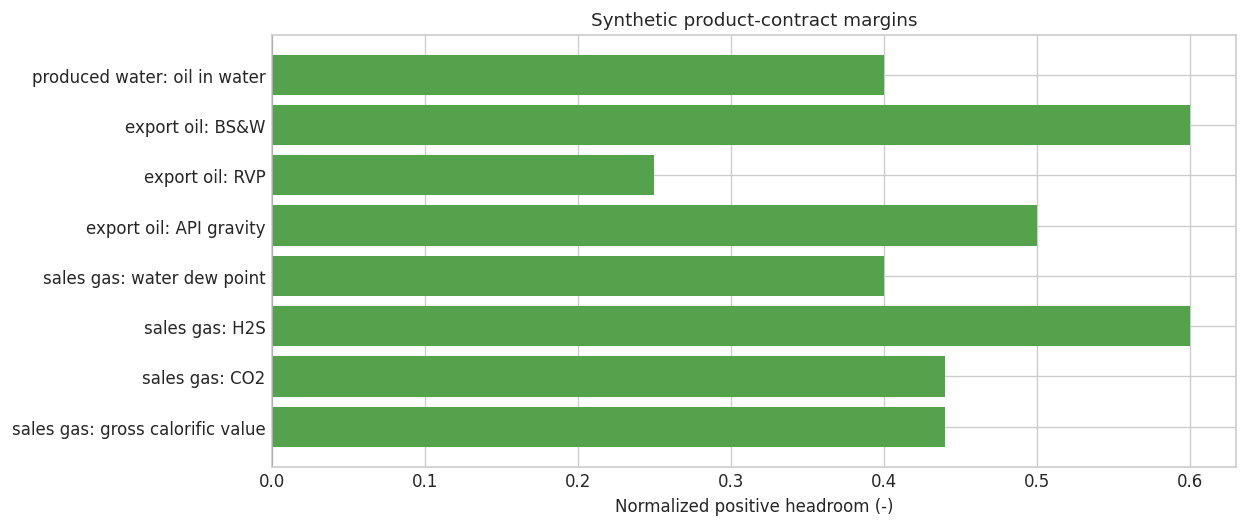

,product,metric,actual,limit,direction,unit,raw headroom,normalized headroom,within limit
0,sales gas,gross calorific value,39.2,37,min,MJ/Sm³,2.2,0.44,True
1,sales gas,CO2,1.4,2.5,max,mol%,1.1,0.44,True
2,sales gas,H2S,2,5,max,ppm,3,0.6,True
3,sales gas,water dew point,-12,-8,max,°C,4,0.4,True
4,export oil,API gravity,35,30,min,°API,5,0.5,True
5,export oil,RVP,0.75,1,max,bara,0.25,0.25,True
6,export oil,BS&W,0.2,0.5,max,vol%,0.3,0.6,True
7,produced water,oil in water,18,30,max,mg/L,12,0.4,True


In [15]:
product_contracts = pd.DataFrame(
    {
        "product": [
            "sales gas",
            "sales gas",
            "sales gas",
            "sales gas",
            "export oil",
            "export oil",
            "export oil",
            "produced water",
        ],
        "metric": [
            "gross calorific value",
            "CO2",
            "H2S",
            "water dew point",
            "API gravity",
            "RVP",
            "BS&W",
            "oil in water",
        ],
        "actual": [39.2, 1.4, 2.0, -12.0, 35.0, 0.75, 0.20, 18.0],
        "limit": [37.0, 2.5, 5.0, -8.0, 30.0, 1.00, 0.50, 30.0],
        "direction": [
            "min",
            "max",
            "max",
            "max",
            "min",
            "max",
            "max",
            "max",
        ],
        "unit": [
            "MJ/Sm³",
            "mol%",
            "ppm",
            "°C",
            "°API",
            "bara",
            "vol%",
            "mg/L",
        ],
        "comparison scale": [5.0, 2.5, 5.0, 10.0, 10.0, 1.0, 0.5, 30.0],
    }
)
product_contracts["raw headroom"] = np.where(
    product_contracts["direction"] == "max",
    product_contracts["limit"] - product_contracts["actual"],
    product_contracts["actual"] - product_contracts["limit"],
)
product_contracts["normalized headroom"] = (
    product_contracts["raw headroom"]
    / product_contracts["comparison scale"]
)
product_contracts["within limit"] = (
    product_contracts["raw headroom"] >= 0.0
)

fig, axis = plt.subplots(figsize=(10.5, 4.5))
labels = (
    product_contracts["product"]
    + ": "
    + product_contracts["metric"]
)
colors = np.where(
    product_contracts["within limit"],
    "#54a24b",
    "#e45756",
)
axis.barh(labels, product_contracts["normalized headroom"], color=colors)
axis.axvline(0.0, color="black", linewidth=1)
axis.set(
    xlabel="Normalized positive headroom (-)",
    title="Synthetic product-contract margins",
)
plt.tight_layout()
plt.show()

display(product_contracts.drop(columns="comparison scale").round(3))


## 13. Gas quality and the commercial handoff

ISO 6976 calculations connect composition to superior calorific value and Wobbe index. The
calorific-value handoff converts standard volume to energy:

$$

E=V_n H_s

$$

where $V_n$ is standard volume in Sm³ and $H_s$ is superior calorific value in MJ/Sm³. Reference
conditions and whether the state is real or ideal are part of the contractual definition, not
plotting details.


,CO2 mol%,GCV MJ/Sm3,Wobbe MJ/Sm3,relative density,energy TJ/d
0,0,43.62,53.43,0.6662,32.87
1,1,43.24,52.59,0.6759,32.59
2,2,42.86,51.76,0.6857,32.3
3,3,42.49,50.95,0.6954,32.02
4,4,42.11,50.15,0.7051,31.74
5,5,41.73,49.36,0.7148,31.45
6,6,41.36,48.59,0.7245,31.17
7,7,40.98,47.83,0.7342,30.89
8,8,40.6,47.08,0.7439,30.6


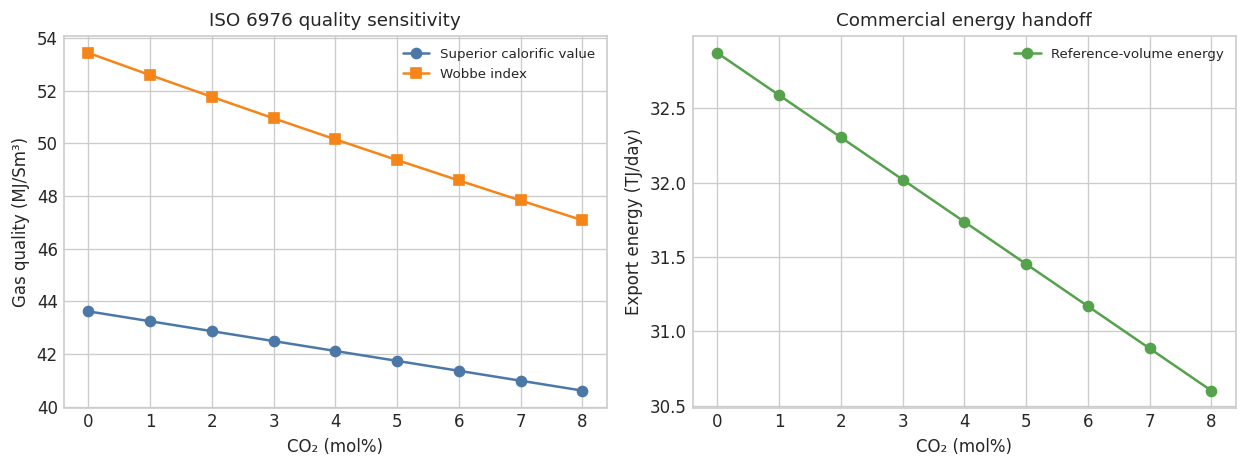

In [16]:
def calculate_iso6976_quality(co2_fraction):
    quality_fluid = SystemSrk(273.15 + 15.0, 1.01325)
    quality_composition = {
        "nitrogen": 0.01,
        "CO2": co2_fraction,
        "methane": 0.85 - co2_fraction,
        "ethane": 0.08,
        "propane": 0.04,
        "n-butane": 0.02,
    }
    for component, amount in quality_composition.items():
        quality_fluid.addComponent(component, amount)
    quality_fluid.setMixingRule(2)
    ThermodynamicOperations(quality_fluid).TPflash()
    quality_fluid.init(2)
    standard = StandardISO6976(quality_fluid)
    standard.setReferenceType("volume")
    standard.setReferenceState("real")
    standard.setVolRefT(15.0)
    standard.setEnergyRefT(25.0)
    standard.calculate()
    return {
        "CO2 mol%": 100.0 * co2_fraction,
        "GCV MJ/Sm3": standard.getValue("SuperiorCalorificValue") / 1_000.0,
        "Wobbe MJ/Sm3": standard.getValue("SuperiorWobbeIndex") / 1_000.0,
        "relative density": standard.getValue("RelativeDensity"),
    }


co2_fractions = np.linspace(0.0, 0.08, 9)
gas_quality = pd.DataFrame(
    [calculate_iso6976_quality(fraction) for fraction in co2_fractions]
)
reference_gas_volume_sm3_d = scenario_results.loc[
    scenario_results["scenario"] == "Reference",
    "gas MSm3/d",
].iloc[0] * 1.0e6
gas_quality["energy TJ/d"] = (
    reference_gas_volume_sm3_d * gas_quality["GCV MJ/Sm3"] / 1.0e6
)
display(gas_quality.round(4))

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.0))
axes[0].plot(
    gas_quality["CO2 mol%"],
    gas_quality["GCV MJ/Sm3"],
    color="#4c78a8",
    marker="o",
    label="Superior calorific value",
)
axes[0].plot(
    gas_quality["CO2 mol%"],
    gas_quality["Wobbe MJ/Sm3"],
    color="#f58518",
    marker="s",
    label="Wobbe index",
)
axes[0].set(
    xlabel="CO₂ (mol%)",
    ylabel="Gas quality (MJ/Sm³)",
    title="ISO 6976 quality sensitivity",
)
axes[0].legend()
axes[1].plot(
    gas_quality["CO2 mol%"],
    gas_quality["energy TJ/d"],
    color="#54a24b",
    marker="o",
    label="Reference-volume energy",
)
axes[1].set(
    xlabel="CO₂ (mol%)",
    ylabel="Export energy (TJ/day)",
    title="Commercial energy handoff",
)
axes[1].legend()
plt.tight_layout()
plt.show()

assert np.all(np.diff(gas_quality["GCV MJ/Sm3"]) < 0.0)
assert np.all(np.diff(gas_quality["energy TJ/d"]) < 0.0)


Increasing CO₂ lowers both energy per standard cubic metre and the nominated daily energy at fixed
volume. A commercial workflow must use custody-transfer composition and approved reference
conditions. The process model supplies a decision-consistent forecast; it does not replace the
metering system or contractual allocation process.


## 14. Energy and emissions follow the physical operating cases

Compressor and utility demand must be tied to the same rates, pressure targets, efficiencies,
availability, and power-supply assumptions as the production forecast. For electricity or
shaft-power demand $E$, the simplified operational emission is

$$m_{CO_2}=E\,EF$$

where $EF$ is an explicitly versioned emission factor. The screen compares gas turbines,
partial electrification, and low-carbon power without claiming a project-specific grid or
lifecycle factor.


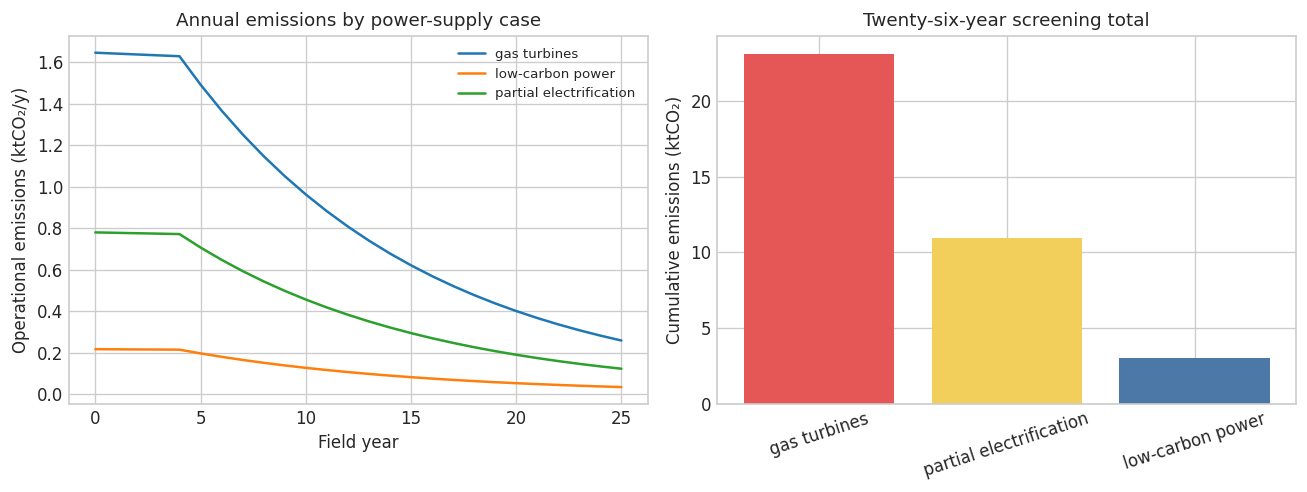

,tCO2
power supply,
gas turbines,2.315e+04
partial electrification,1.096e+04
low-carbon power,"3,046"


In [17]:
power_supply_cases = pd.DataFrame(
    {
        "power supply": [
            "gas turbines",
            "partial electrification",
            "low-carbon power",
        ],
        "emission factor tCO2/MWh": [0.190, 0.090, 0.025],
    }
)
availability_curve = np.clip(0.97 - 0.0025 * field_years, 0.88, 1.0)
base_facility["availability"] = availability_curve
base_facility["total power MW"] = 1.15 * base_facility["compression MW"]

emission_records = []
for _, power_case in power_supply_cases.iterrows():
    annual_energy_mwh = (
        base_facility["total power MW"]
        * 8_760.0
        * base_facility["availability"]
    )
    annual_emissions = (
        annual_energy_mwh
        * power_case["emission factor tCO2/MWh"]
    )
    for year, energy, emissions in zip(
        base_facility["year"],
        annual_energy_mwh,
        annual_emissions,
    ):
        emission_records.append(
            {
                "power supply": power_case["power supply"],
                "year": int(year),
                "energy MWh/y": energy,
                "emissions tCO2/y": emissions,
            }
        )
emissions = pd.DataFrame(emission_records)
cumulative_emissions = (
    emissions.groupby("power supply")["emissions tCO2/y"]
    .sum()
    .sort_values(ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for name, group in emissions.groupby("power supply"):
    axes[0].plot(
        group["year"],
        group["emissions tCO2/y"] / 1_000.0,
        label=name,
    )
axes[0].set(
    xlabel="Field year",
    ylabel="Operational emissions (ktCO₂/y)",
    title="Annual emissions by power-supply case",
)
axes[0].legend()
axes[1].bar(
    cumulative_emissions.index,
    cumulative_emissions.to_numpy() / 1_000.0,
    color=["#e45756", "#f2cf5b", "#4c78a8"],
)
axes[1].set(
    ylabel="Cumulative emissions (ktCO₂)",
    title="Twenty-six-year screening total",
)
axes[1].tick_params(axis="x", rotation=18)
plt.tight_layout()
plt.show()

display(cumulative_emissions.rename("tCO2").to_frame().round(0))


## 15. Deterministic economics consumes governed production and emissions

A project economic model should include fiscal terms, price scenarios, tariffs, foreign
exchange, abandonment security, working interest, timing, and uncertainty. The transparent
screen below keeps production realization, availability, energy, emissions, and economic
assumptions linked by `case_id`.

Net present value is

$$NPV_k=\sum_{t=0}^{N}\frac{CF_{t,k}}{(1+r)^t}$$

Mixing a high production profile with low costs and a favorable price percentile without a
defined joint realization would break the contract architecture established above.


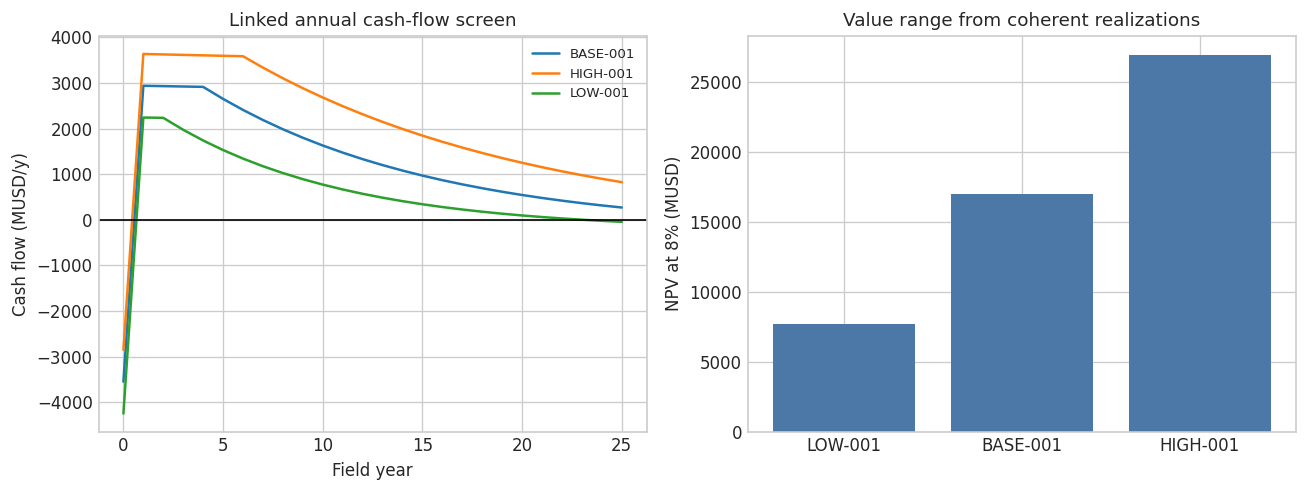

,NPV MUSD
case_id,
LOW-001,"7,699"
BASE-001,1.697e+04
HIGH-001,2.694e+04


In [18]:
economic_assumptions = {
    "oil price USD/bbl": 75.0,
    "gas price USD/MMBtu": 10.0,
    "gas energy GJ/Sm3": 0.039,
    "GJ/MMBtu": 1.055056,
    "fixed opex MUSD/y": 230.0,
    "variable opex USD/boe": 4.0,
    "carbon price USD/tCO2": 100.0,
    "initial capex MUSD": 6_500.0,
    "discount rate": 0.08,
}

economic_records = []
for case_id, group in reservoir_forecast.groupby("case_id"):
    group = group.sort_values("year").copy()
    availability = np.clip(0.97 - 0.0025 * group["year"], 0.88, 1.0)
    oil_bbl_y = group["oil kboe/d"] * 1_000.0 * 365.0 * availability
    gas_sm3_y = group["gas MSm3/d"] * 1.0e6 * 365.0 * availability
    oil_revenue = (
        oil_bbl_y
        * economic_assumptions["oil price USD/bbl"]
        / 1.0e6
    )
    gas_revenue = (
        gas_sm3_y
        * economic_assumptions["gas energy GJ/Sm3"]
        / economic_assumptions["GJ/MMBtu"]
        * economic_assumptions["gas price USD/MMBtu"]
        / 1.0e6
    )
    variable_opex = (
        oil_bbl_y
        * economic_assumptions["variable opex USD/boe"]
        / 1.0e6
    )
    case_facility = facility.loc[facility["case_id"] == case_id].copy()
    annual_emissions = (
        1.15
        * case_facility["compression MW"].to_numpy()
        * 8_760.0
        * availability.to_numpy()
        * 0.190
    )
    carbon_cost = (
        annual_emissions
        * economic_assumptions["carbon price USD/tCO2"]
        / 1.0e6
    )
    cash_flow = (
        oil_revenue
        + gas_revenue
        - economic_assumptions["fixed opex MUSD/y"]
        - variable_opex
        - carbon_cost
    )
    cash_flow.iloc[0] -= economic_assumptions["initial capex MUSD"]
    for year, value in zip(group["year"], cash_flow):
        economic_records.append(
            {
                "case_id": case_id,
                "year": int(year),
                "cash flow MUSD": value,
            }
        )

economics = pd.DataFrame(economic_records)
economics["discount factor"] = (
    1.0 + economic_assumptions["discount rate"]
) ** economics["year"]
economics["discounted cash flow MUSD"] = (
    economics["cash flow MUSD"] / economics["discount factor"]
)
npv_by_case = (
    economics.groupby("case_id")["discounted cash flow MUSD"]
    .sum()
    .sort_values()
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for case_id, group in economics.groupby("case_id"):
    axes[0].plot(
        group["year"],
        group["cash flow MUSD"],
        label=case_id,
    )
axes[0].axhline(0.0, color="black", linewidth=1)
axes[0].set(
    xlabel="Field year",
    ylabel="Cash flow (MUSD/y)",
    title="Linked annual cash-flow screen",
)
axes[0].legend()
axes[1].bar(npv_by_case.index, npv_by_case.to_numpy(), color="#4c78a8")
axes[1].set(
    ylabel="NPV at 8% (MUSD)",
    title="Value range from coherent realizations",
)
plt.tight_layout()
plt.show()

display(npv_by_case.rename("NPV MUSD").to_frame().round(0))


## 16. Carry physical uncertainty into value

The process result anchors a compact probabilistic value screen. Each realization samples initial
gas rate, decline, uptime, gas price, operating cost, discount rate, and CO₂ price. Discounted net
present value is

$$

NPV=-CAPEX+\sum_{t=1}^{N}\frac{R_t-OPEX_t-C_t}{(1+r)^t}

$$

where revenue $R_t$, operating cost $OPEX_t$, carbon cost $C_t$, and discount rate $r$ are defined
for the same realization. The distributions are illustrative and must be replaced by governed
subsurface, facility, fiscal, and market uncertainty for an investment decision.


,metric,value BNOK
0,P10 NPV,-2.785
1,P50 NPV,-1.8
2,P90 NPV,-0.518


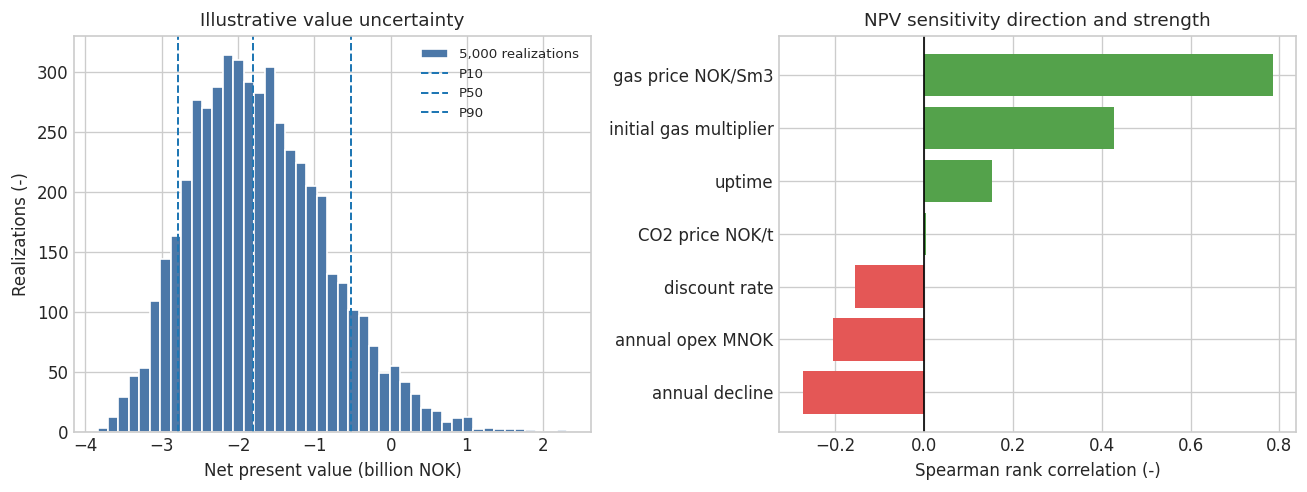

In [19]:
rng = np.random.default_rng(20260806)
sample_count = 5_000
project_years = np.arange(1, 21)

uncertainty_inputs = pd.DataFrame(
    {
        "initial gas multiplier": rng.triangular(0.75, 1.0, 1.25, sample_count),
        "annual decline": rng.triangular(0.035, 0.065, 0.10, sample_count),
        "uptime": rng.triangular(0.84, 0.93, 0.98, sample_count),
        "gas price NOK/Sm3": rng.triangular(1.4, 2.3, 3.5, sample_count),
        "annual opex MNOK": rng.triangular(90.0, 130.0, 190.0, sample_count),
        "discount rate": rng.triangular(0.06, 0.08, 0.12, sample_count),
        "CO2 price NOK/t": rng.triangular(700.0, 1_200.0, 2_000.0, sample_count),
    }
)

reference_annual_volume_sm3 = reference_gas_volume_sm3_d * 365.0
reference_emissions_t_y = emissions.loc[
    (emissions["power supply"] == "gas turbines")
    & (emissions["year"] == 0),
    "emissions tCO2/y",
].iloc[0]
capital_cost_nok = 4.2e9
npv_nok = np.full(sample_count, -capital_cost_nok)

for year in project_years:
    annual_volume_sm3 = (
        reference_annual_volume_sm3
        * uncertainty_inputs["initial gas multiplier"]
        * (1.0 - uncertainty_inputs["annual decline"]) ** (year - 1)
        * uncertainty_inputs["uptime"]
    )
    annual_revenue_nok = annual_volume_sm3 * uncertainty_inputs["gas price NOK/Sm3"]
    annual_opex_nok = uncertainty_inputs["annual opex MNOK"] * 1.0e6
    annual_carbon_cost_nok = (
        reference_emissions_t_y
        * uncertainty_inputs["initial gas multiplier"]
        * uncertainty_inputs["CO2 price NOK/t"]
    )
    discount_factor = (1.0 + uncertainty_inputs["discount rate"]) ** year
    npv_nok += (
        annual_revenue_nok - annual_opex_nok - annual_carbon_cost_nok
    ) / discount_factor

uncertainty_inputs["NPV BNOK"] = npv_nok / 1.0e9
npv_percentiles = np.percentile(uncertainty_inputs["NPV BNOK"], [10, 50, 90])

sensitivity_rows = []
for column in uncertainty_inputs.columns[:-1]:
    correlation = stats.spearmanr(
        uncertainty_inputs[column],
        uncertainty_inputs["NPV BNOK"],
    ).statistic
    sensitivity_rows.append(
        {
            "input": column,
            "Spearman correlation": correlation,
        }
    )
sensitivity = pd.DataFrame(sensitivity_rows).sort_values("Spearman correlation")

display(
    pd.DataFrame(
        {
            "metric": ["P10 NPV", "P50 NPV", "P90 NPV"],
            "value BNOK": npv_percentiles,
        }
    ).round(3)
)

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.2))
axes[0].hist(
    uncertainty_inputs["NPV BNOK"],
    bins=45,
    color="#4c78a8",
    edgecolor="white",
    label=f"{sample_count:,} realizations",
)
for percentile, label in zip(npv_percentiles, ["P10", "P50", "P90"]):
    axes[0].axvline(percentile, linestyle="--", linewidth=1.2, label=label)
axes[0].set(
    xlabel="Net present value (billion NOK)",
    ylabel="Realizations (-)",
    title="Illustrative value uncertainty",
)
axes[0].legend()
bar_colors = np.where(
    sensitivity["Spearman correlation"] >= 0.0,
    "#54a24b",
    "#e45756",
)
axes[1].barh(
    sensitivity["input"],
    sensitivity["Spearman correlation"],
    color=bar_colors,
)
axes[1].axvline(0.0, color="black", linewidth=1)
axes[1].set(
    xlabel="Spearman rank correlation (-)",
    title="NPV sensitivity direction and strength",
)
plt.tight_layout()
plt.show()

assert np.isfinite(uncertainty_inputs.to_numpy()).all()
assert npv_percentiles[0] < npv_percentiles[1] < npv_percentiles[2]


The percentile range is wider than a single deterministic answer and the rank correlations reveal
which assumptions dominate this teaching case. Correlation is not causation and does not allocate
risk ownership. A decision model should retain realization IDs so physical, availability, price,
fiscal, emissions, and cost assumptions can be traced back to their approved sources.


## 17. Operations, reliability, and late-life decisions

Process capacity is not production capacity unless equipment is available and operating
constraints are satisfied. Historian data, failure taxonomy, inspection, maintenance plans,
common-cause dependencies, spares, and crew logistics belong in the RAM and integrity model.
NeqSim supplies state normalization and physical consequence, not the failure database.

The Monte Carlo screen quantifies annual availability from planned downtime, failure count,
and repair duration. Its purpose is to show how a reliability distribution enters production
and value; it is not calibrated to an asset.


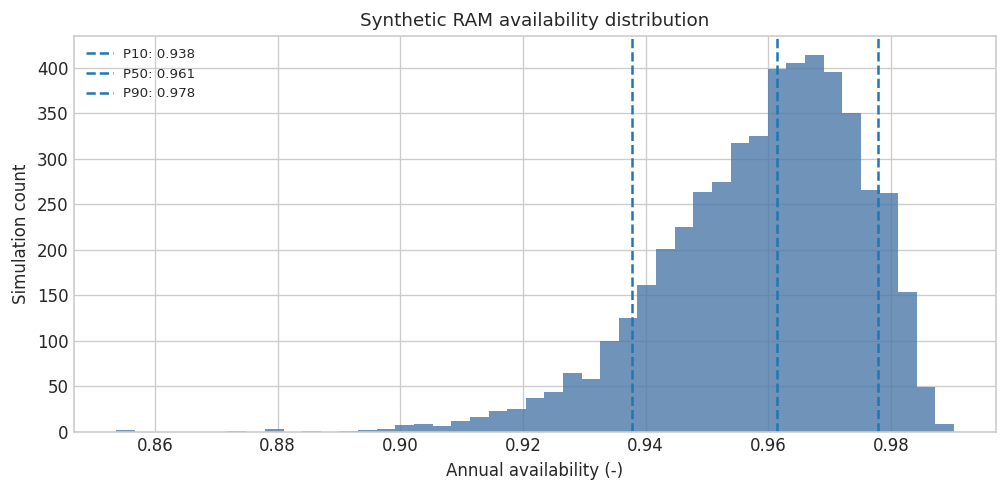

,availability percentile,availability,oil kboe/d after availability
0,P10,0.9378,50.69
1,P50,0.9615,51.96
2,P90,0.9779,52.85


In [20]:
random_generator = np.random.default_rng(20260806)
simulations = 5_000
failure_count = random_generator.poisson(3.2, size=simulations)
corrective_downtime_h = random_generator.gamma(
    shape=2.0 * failure_count,
    scale=32.0,
)
planned_downtime_h = random_generator.normal(
    loc=160.0,
    scale=24.0,
    size=simulations,
)
total_downtime_h = np.clip(
    corrective_downtime_h + planned_downtime_h,
    0.0,
    8_760.0,
)
simulated_availability = 1.0 - total_downtime_h / 8_760.0
availability_quantiles = pd.Series(
    np.quantile(simulated_availability, [0.10, 0.50, 0.90]),
    index=["P10", "P50", "P90"],
    name="annual availability",
)

base_year_10 = reservoir_forecast.query(
    "case_id == 'BASE-001' and year == 10"
).iloc[0]
availability_impact = pd.DataFrame(
    {
        "availability percentile": availability_quantiles.index,
        "availability": availability_quantiles.to_numpy(),
        "oil kboe/d after availability": (
            base_year_10["oil kboe/d"]
            * availability_quantiles.to_numpy()
        ),
    }
)

fig, axis = plt.subplots(figsize=(8.5, 4.2))
axis.hist(
    simulated_availability,
    bins=45,
    color="#4c78a8",
    alpha=0.8,
)
for label, value in availability_quantiles.items():
    axis.axvline(value, linestyle="--", label=f"{label}: {value:.3f}")
axis.set(
    xlabel="Annual availability (-)",
    ylabel="Simulation count",
    title="Synthetic RAM availability distribution",
)
axis.legend()
plt.tight_layout()
plt.show()

display(availability_impact.round(4))


## 18. Decision gates: what must mature before commitment

Each gate tightens uncertainty, model fidelity, interfaces, assurance, and ownership. NeqSim
can provide a common open calculation layer, but it cannot approve reserves, certify wells or
structures, establish custody transfer, replace HAZOP/QRA, or authorize investment.


In [21]:
decision_gates = pd.DataFrame(
    {
        "gate": ["DG0", "DG1", "DG2", "DG3", "DG4", "Operate", "Cessation"],
        "decision": [
            "Frame opportunity",
            "Confirm business case range",
            "Select concept",
            "Freeze basis for execution",
            "Start up and accept performance",
            "Optimize safely within constraints",
            "Stop production and execute retirement",
        ],
        "minimum integrated evidence": [
            "Data provenance, ranges, analogues, fluid-sampling plan",
            "PVT basis, reservoir range, concept capacities, economics",
            "Selected wells/SURF/facility, flow assurance, products, RAM",
            "Design cases, equipment, controls, safety, schedule, cost",
            "Commissioning evidence, tests, handover, operating envelope",
            "Historian reconciliation, integrity, maintenance, emissions",
            "Economic limit, P&A, cleaning, removal, waste, liabilities",
        ],
        "NeqSim role": [
            "Supporting fluid and process screens",
            "Supporting PVT checks; integrated process cases",
            "Process/energy engine plus cross-discipline boundaries",
            "Auditable process cases and consequence calculations",
            "Start-up, performance, and process-model reconciliation",
            "Process twin, diagnosis, optimization, and consequence",
            "Inventory, depressurization, purge, and flushing support",
        ],
    }
)
display(decision_gates)


,gate,decision,minimum integrated evidence,NeqSim role
0,DG0,Frame opportunity,"Data provenance, ranges, analogues, fluid-sampling plan",Supporting fluid and process screens
1,DG1,Confirm business case range,"PVT basis, reservoir range, concept capacities, economics",Supporting PVT checks; integrated process cases
2,DG2,Select concept,"Selected wells/SURF/facility, flow assurance, products, RAM",Process/energy engine plus cross-discipline boundaries
3,DG3,Freeze basis for execution,"Design cases, equipment, controls, safety, schedule, cost",Auditable process cases and consequence calculations
4,DG4,Start up and accept performance,"Commissioning evidence, tests, handover, operating envelope","Start-up, performance, and process-model reconciliation"
5,Operate,Optimize safely within constraints,"Historian reconciliation, integrity, maintenance, emissions","Process twin, diagnosis, optimization, and consequence"
6,Cessation,Stop production and execute retirement,"Economic limit, P&A, cleaning, removal, waste, liabilities","Inventory, depressurization, purge, and flushing support"


## 19. Convert operating scenarios into explicit decision gates

The final application combines process convergence, balance closure, capacity, and gas-quality
checks. The limits are illustrative screening thresholds. A real project must source each limit
from design requirements, operating envelopes, product contracts, integrity management, and
regulatory obligations.


,scenario,gates passed,all gates passed,mass residual
0,Reference,6,True,4.094e-14
1,Turndown,6,True,4.107e-14
2,High rate,6,True,4.107e-14
3,High water,6,True,6.034e-14
4,CO2 rich,5,False,5.161e-14
5,Cold inlet,6,True,1.164e-14


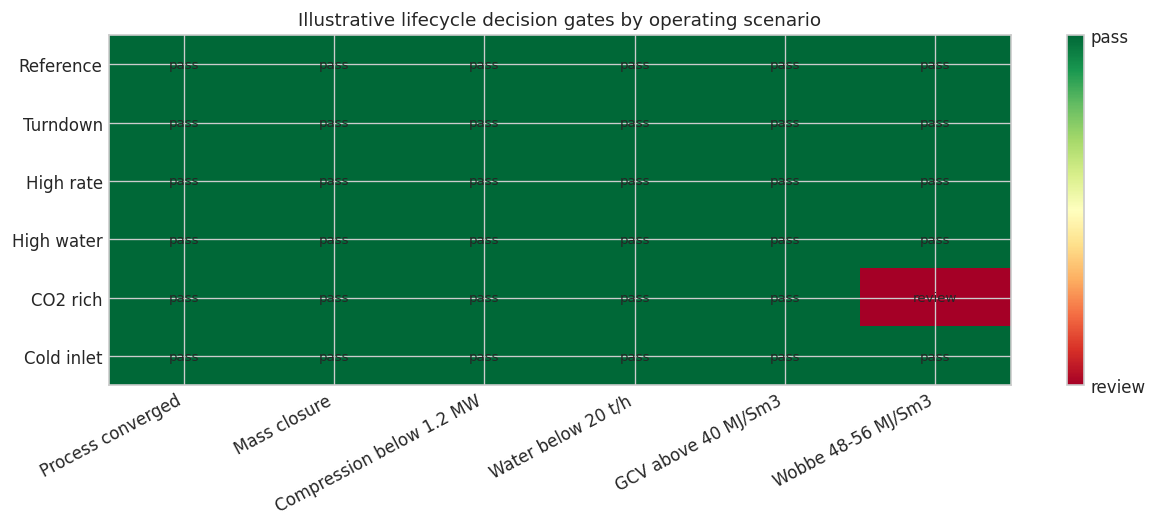

In [22]:
decision_gate_matrix = pd.DataFrame(
    {
        "Process converged": scenario_results["process success"].to_numpy(),
        "Mass closure": (scenario_results["mass residual"] < 1.0e-8).to_numpy(),
        "Compression below 1.2 MW": (
            scenario_results["compressor MW"] < 1.2
        ).to_numpy(),
        "Water below 20 t/h": (scenario_results["water t/h"] < 20.0).to_numpy(),
        "GCV above 40 MJ/Sm3": (
            scenario_results["GCV MJ/Sm3"] > 40.0
        ).to_numpy(),
        "Wobbe 48-56 MJ/Sm3": scenario_results["Wobbe MJ/Sm3"].between(
            48.0,
            56.0,
        ).to_numpy(),
    },
    index=scenario_results["scenario"],
)
scenario_results["gates passed"] = decision_gate_matrix.sum(axis=1).to_numpy()
scenario_results["all gates passed"] = decision_gate_matrix.all(axis=1).to_numpy()

display(
    scenario_results[
        [
            "scenario",
            "gates passed",
            "all gates passed",
            "mass residual",
        ]
    ]
)

fig, axis = plt.subplots(figsize=(10.5, 4.5))
gate_image = axis.imshow(
    decision_gate_matrix.astype(int),
    cmap="RdYlGn",
    vmin=0,
    vmax=1,
    aspect="auto",
)
axis.set_xticks(
    np.arange(decision_gate_matrix.shape[1]),
    labels=decision_gate_matrix.columns,
)
axis.set_yticks(
    np.arange(decision_gate_matrix.shape[0]),
    labels=decision_gate_matrix.index,
)
plt.setp(axis.get_xticklabels(), rotation=28, ha="right")
for row in range(decision_gate_matrix.shape[0]):
    for column in range(decision_gate_matrix.shape[1]):
        label = "pass" if decision_gate_matrix.iloc[row, column] else "review"
        axis.text(column, row, label, ha="center", va="center", fontsize=8)
axis.set_title("Illustrative lifecycle decision gates by operating scenario")
colorbar = fig.colorbar(gate_image, ax=axis, ticks=[0, 1])
colorbar.ax.set_yticklabels(["review", "pass"])
plt.tight_layout()
plt.show()

assert decision_gate_matrix["Process converged"].all()
assert decision_gate_matrix["Mass closure"].all()
assert (~decision_gate_matrix).any(axis=None)
assert scenario_results[["gates passed", "all gates passed"]].notna().all().all()


The matrix makes trade-offs visible: numerically valid scenarios can still require engineering or
commercial review. A failed screen is not automatically an infeasible design, and a passing screen
is not approval. The next owner must assess the underlying evidence and either accept the case,
request refinement, or reject it with a documented reason.

### Applicability and limitations

- The compositional process is a steady, compact teaching model without equipment sizing,
  controllers, recycle, relief, or detailed treatment.
- The density comparison uses synthetic observations and performs no PVT regression.
- The dry-gas hydraulic screen omits elevation, heat transfer, phase appearance, terrain slugging,
  and transient boundary changes.
- ISO 6976 values are calculated at stated reference conditions but are not custody-transfer data.
- Field-life and economic distributions are illustrative and exclude fiscal detail, liquids value,
  abandonment tax effects, correlations, schedule, and decision flexibility.
- Scenario limits are pedagogical; governed project criteria must replace them.


## 20. Dependency-ordered learning path through NeqSim-Colab

Use this notebook as the map and the following notebooks for depth:

1. **PVT and fluid interfaces:** [laboratory-to-simulator PVT workflow](../PVT/pvt_workflow_from_lab_to_simulator.ipynb),
   [modern fluid properties](../thermodynamics/modern_fluid_property_workflow.ipynb), and
   [ThermoML testing and tuning](../thermodynamics/thermoml_model_accuracy_and_parameter_tuning.ipynb).
2. **Reservoir and uncertainty:** [rock flow](../reservoir/rock_flow_pore_to_field_neqsim.ipynb),
   [OPM Flow coupling](../reservoir/neqsim_opm_flow_blackoil_coupling.ipynb), and
   [ERT field-development uncertainty](../reservoir/ert_neqsim_integrated_field_development.ipynb).
3. **Wells, SURF, and control:** [integrated wells](../well/integrated_wells_drilling_completion_lift_injection_intervention.ipynb),
   [subsea systems](../subseaequipment/subseaequipment.ipynb),
   [minimum-flow hydraulics](../fluidflow/minimum_flow_long_multiphase_flowline.ipynb), and
   [dynamic SURF–topside control](../process/integrated_dynamic_surf_topside_control.ipynb).
4. **Facilities and products:** [integrated oil and gas process](../process/oil_and_gas_Process_with_ngl_stabilizer_and_tex_process.ipynb),
   [produced water, sand, and chemicals](../production/produced_water_sand_chemicals_management.ipynb),
   and [energy and emissions](../power/neqsim_ecalc_integrated_energy_emissions.ipynb).
5. **Export and value:** [European gas sales](../gasvaluechain/european_gas_sales_market_foundation.ipynb),
   [crude-oil sales](../gasvaluechain/european_crude_oil_sales_foundation.ipynb), and
   [stochastic reservoir-to-market optimization](../reservoir/stochastic_reservoir_to_market_optimization.ipynb).
6. **Operate and retire:** [operations and asset management](../operations/operations_asset_management_with_neqsim.ipynb)
   and [facility lifecycle](../operations/facility_lifecycle_commissioning_to_decommissioning.ipynb).

The sequence is a dependency map, not a substitute for project assurance or specialist tools.


In [23]:
base_constraints = base_facility["active constraint"]
ordered_npvs = [
    npv_by_case.loc["LOW-001"],
    npv_by_case.loc["BASE-001"],
    npv_by_case.loc["HIGH-001"],
]
validation = pd.DataFrame(
    {
        "check": [
            "Source-built NeqSim commit and JAR identity recorded",
            "NeqSim is never primary for PVT authoring",
            "Synthetic laboratory PVT quality checks pass",
            "Scenario registry has unique coherent case identifiers",
            "Three nearby NeqSim process cases close mass",
            "Compressor demand changes monotonically with feed rate",
            "Reservoir forecast covers all cases and years",
            "Well/SURF screen produces finite margins",
            "BASE-001 facility constraint migrates over field life",
            "Synthetic product measurements remain within limits",
            "Economic value is ordered low, base, high",
            "Reliability percentiles are ordered",
            "Every lifecycle stage is represented in the role matrix",
            "All six connected ProcessSystem scenarios converge",
            "Connected scenario mass closure is below 1e-8",
            "Supporting NeqSim PVT density residuals remain below 2%",
            "Supporting gas density increases with pressure",
            "SURF Darcy pressure loss increases with flow",
            "SURF hydraulic screen remains turbulent",
            "ISO 6976 gas-quality values are finite",
            "GCV decreases as CO2 increases",
            "All probabilistic value realizations are finite",
            "Probabilistic NPV percentiles are ordered",
            "Scenario gate matrix retains review outcomes",
            "Scenario gate summary is complete",
        ],
        "passed": [
            len(neqsim_commit) == 40 and len(neqsim_jar_sha256) == 64,
            role_matrix[:, pvt_column].max() <= 1,
            pvt_quality_checks["passed"].all(),
            scenario_registry["case_id"].is_unique,
            process_case_results["relative mass residual"].max() < 1.0e-8,
            process_case_results["compressor power kW"].is_monotonic_increasing,
            len(reservoir_forecast) == 3 * len(field_years),
            np.isfinite(
                flow_screen[
                    ["wellhead margin bar", "flowline utilization"]
                ].to_numpy()
            ).all(),
            base_constraints.nunique() >= 2,
            product_contracts["within limit"].all(),
            ordered_npvs[0] < ordered_npvs[1] < ordered_npvs[2],
            availability_quantiles.is_monotonic_increasing,
            len(stages) == role_matrix.shape[0],
            scenario_results["process success"].all(),
            scenario_results["mass residual"].max() < 1.0e-8,
            np.max(np.abs(density_residual_percent)) < 2.0,
            np.all(np.diff(model_density_kg_m3) > 0.0),
            np.all(np.diff(screen_pressure_drop_bar) > 0.0),
            np.all(screen_reynolds > 4_000.0),
            np.isfinite(gas_quality.select_dtypes("number").to_numpy()).all(),
            np.all(np.diff(gas_quality["GCV MJ/Sm3"]) < 0.0),
            np.isfinite(uncertainty_inputs.to_numpy()).all(),
            npv_percentiles[0] < npv_percentiles[1] < npv_percentiles[2],
            (~decision_gate_matrix).any(axis=None),
            scenario_results[["gates passed", "all gates passed"]]
            .notna()
            .all()
            .all(),
        ],
    }
)
if not validation["passed"].all():
    raise AssertionError(validation.to_string(index=False))

representative_results = pd.DataFrame(
    {
        "result": [
            "NeqSim supporting process gas handoff",
            "NeqSim supporting process oil handoff",
            "NeqSim supporting process water handoff",
            "Reference export-compressor power",
            "Initial BASE-001 active facility constraint",
            "Late BASE-001 active facility constraint",
            "BASE-001 economic-screen NPV",
            "RAM P50 annual availability",
        ],
        "value": [
            base_process["gas kg/h"] / 1_000.0,
            base_process["oil-processing feed kg/h"] / 1_000.0,
            base_process["produced water kg/h"] / 1_000.0,
            base_process["compressor power kW"] / 1_000.0,
            base_constraints.iloc[0],
            base_constraints.iloc[-1],
            npv_by_case.loc["BASE-001"],
            availability_quantiles.loc["P50"],
        ],
        "unit or interpretation": [
            "t/h",
            "t/h",
            "t/h",
            "MW",
            "screening bottleneck",
            "screening bottleneck",
            "MUSD at 8%",
            "fraction",
        ],
    }
)
display(validation)
display(representative_results)


integrated_application_summary = pd.DataFrame(
    {
        "result": [
            "Connected process scenarios",
            "Maximum connected mass residual",
            "Reference cooling duty",
            "Reference export GCV",
            "Maximum dry-gas hydraulic drop",
            "P10 / P50 / P90 probabilistic NPV",
        ],
        "value": [
            len(scenario_results),
            scenario_results["mass residual"].max(),
            scenario_results.loc[
                scenario_results["scenario"] == "Reference", "cooling MW"
            ].iloc[0],
            scenario_results.loc[
                scenario_results["scenario"] == "Reference", "GCV MJ/Sm3"
            ].iloc[0],
            screen_pressure_drop_bar.max(),
            ", ".join(f"{value:.3f}" for value in npv_percentiles),
        ],
        "unit or interpretation": [
            "cases",
            "fraction",
            "MW",
            "MJ/Sm3",
            "bar across 80 km",
            "billion NOK",
        ],
    }
)
display(integrated_application_summary)
print(
    f"Validated {len(validation)} lifecycle checks, "
    f"{len(scenario_results)} connected process cases, "
    f"{len(pvt_pressures_bara)} PVT-support states, "
    f"{len(screen_mass_flow_kg_s)} hydraulic points, and "
    f"{sample_count:,} probabilistic value realizations."
)


Validated 25 lifecycle checks, 6 connected process cases, 6 PVT-support states, 9 hydraulic points, and 5,000 probabilistic value realizations.


,check,passed
0,Source-built NeqSim commit and JAR identity recorded,True
1,NeqSim is never primary for PVT authoring,True
2,Synthetic laboratory PVT quality checks pass,True
3,Scenario registry has unique coherent case identifiers,True
4,Three nearby NeqSim process cases close mass,True
5,Compressor demand changes monotonically with feed rate,True
6,Reservoir forecast covers all cases and years,True
7,Well/SURF screen produces finite margins,True
8,BASE-001 facility constraint migrates over field life,True
9,Synthetic product measurements remain within limits,True


,result,value,unit or interpretation
0,NeqSim supporting process gas handoff,25.28,t/h
1,NeqSim supporting process oil handoff,119.5,t/h
2,NeqSim supporting process water handoff,5.174,t/h
3,Reference export-compressor power,0.8865,MW
4,Initial BASE-001 active facility constraint,gas compression,screening bottleneck
5,Late BASE-001 active facility constraint,water handling,screening bottleneck
6,BASE-001 economic-screen NPV,1.697e+04,MUSD at 8%
7,RAM P50 annual availability,0.9615,fraction


,result,value,unit or interpretation
0,Connected process scenarios,6,cases
1,Maximum connected mass residual,6.034e-14,fraction
2,Reference cooling duty,2.137,MW
3,Reference export GCV,43.56,MJ/Sm3
4,Maximum dry-gas hydraulic drop,0.9197,bar across 80 km
5,P10 / P50 / P90 probabilistic NPV,"-2.785, -1.800, -0.518",billion NOK


## Interpretation, validation level, and limitations

The notebook demonstrates a governed architecture rather than one universal simulator. The
strongest evidence is the source-built NeqSim process execution, exact three-phase mass
closure, nearby-case continuity, explicit model identities, physical bounds, and internally
consistent realization checks. The synthetic PVT trends, reservoir forecasts, well/SURF
margins, product measurements, RAM distribution, emissions, and economics are educational
screens and are not validated against field data.

Important limitations:

- The PVT table is synthetic. A qualified laboratory and specialist PVT package must own the
  real fluid characterization, EOS regression, uncertainty, and reservoir export.
- The compact NeqSim process fluids are downstream translations, not a reservoir-fluid
  model and not adequate for every compositional, wax, hydrate, or product-quality question.
- Reservoir, well, flowline, capacity, reliability, emissions, price, and cost models are
  reduced illustrations. Detailed studies must use calibrated domain models and measured
  equipment envelopes.
- Steady screens omit dynamic accumulation, controls, trips, start-up, shutdown, terrain
  liquid inventory, slugging, and shared-resource dependencies.
- Commercial and regulatory acceptance requires project-specific contracts, standards,
  measurement uncertainty, fiscal terms, approvals, and independent assurance.

Suggested exercises are to replace the synthetic PVT contract with a public laboratory
dataset, import an OPM Flow ensemble without breaking `case_id`, rerun selected process cases
compositionally, add compressor and water-treatment alternatives, and compare value using
correlated price, availability, schedule, and subsurface realizations.

**NeqSim improvement assessment:** no new upstream defect or missing public API was required by
this notebook. The source-built separator, stream, and compressor APIs supported the intended
composable handoff and validation workflow.


### Further extensions and references

Try these extensions while preserving the ownership boundary:

1. Replace the synthetic density points with an approved public dataset, carry measurement
   uncertainty, and document the PVT specialist's acceptance criteria.
2. Pass multiple governed reservoir realizations through the reusable process function and retain
   realization IDs through the economic output.
3. Replace the dry-gas pressure-drop screen with a supported NeqSim pipeline model and compare
   steady and transient boundaries.
4. Add equipment capacity curves, availability states, export specifications, and traceable reasons
   for every rejected scenario.
5. Add liquids value, fiscal terms, decommissioning cash flow, and emissions uncertainty without
   breaking the link to the physical scenario.

Current official references used by this notebook:

- [NeqSim documentation](https://equinor.github.io/neqsim/)
- [Thermodynamic models](https://equinor.github.io/neqsim/thermo/thermodynamic_models)
- [PVT and fluid characterization](https://equinor.github.io/neqsim/thermo/pvt_fluid_characterization)
- [PVT simulation package](https://equinor.github.io/neqsim/pvtsimulation/)
- [Process simulation recipes](https://equinor.github.io/neqsim/cookbook/process-recipes.html)
- [Process design guide](https://equinor.github.io/neqsim/process/process_design_guide)

The PVT references describe available functionality. They do not change this notebook's governance
rule: NeqSim supports the approved PVT basis; laboratory, characterization, and reservoir-model
specialists remain accountable for that basis.
